# Project Introduction [complexity]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **complexity classification of text**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup, Shared Imports & Reproducibility](#section-0-environment-setup-shared-imports-reproducibility)
  - [0.1 Environment & Dependencies](#section-0-1-environment-dependencies)
  - [0.2 Experiment Configuration](#section-0-2-experiment-configuration)
  - [0.3 Shared Utils Imports](#section-0-3-shared-utils-imports)
- [SECTION 1 — Data Loading & Inspection](#section-1-data-loading-inspection)
  - [1.1 Results](#section-1-1-results)
- [SECTION 2 — Data Preparation](#section-2-data-preparation)
  - [2.1 Preprocessing Steps](#section-2-1-preprocessing-steps)
  - [2.2 Train/Val/Test Split](#section-2-2-train-val-test-split)
- [SECTION 3 — Baseline Models](#section-3-baseline-models)
  - [3.1 Preparation & Architecture](#section-3-1-preparation-architecture)
  - [3.2 Training](#section-3-2-training)
  - [3.3 Results](#section-3-3-results)
- [SECTION 4 — Static Embeddings + Models (FastText, MLP + CNN)](#section-4-static-embeddings-models)
  - [4.1 Preparation & Architecture](#section-4-1-preparation-architecture)
  - [4.2 Training](#section-4-2-training)
  - [4.3 Results](#section-4-3-results)
- [SECTION 5 — Recurrent Model (BiLSTM)](#section-5-recurrent-model-bilstm)
  - [5.1 Preparation & Architecture](#section-5-1-preparation-architecture)
  - [5.2 Training](#section-5-2-training)
  - [5.3 Results](#section-5-3-results)
- [SECTION 6 — Transformer Fine-Tuning](#section-6-transformer-fine-tuning)
  - [6.1 Preparation & Architecture](#section-6-1-preparation-architecture)
  - [6.2 Training](#section-6-2-training)
    - [6.2.1 Reference DistilBERT](#section-6-2-1-reference-distilbert)
    - [6.2.2 Alternative RoBERTa](#section-6-2-2-alternative-roberta)
    - [6.2.3 DeBERTa-v3-base](#section-6-2-3-deberta-v3-base)
  - [6.3 Results](#section-6-3-results)
- [SECTION 7 — Cross-Dataset Evaluation](#section-7-cross-dataset-evaluation)
  - [7.1 Classical & Deep Models](#section-7-1-classical-deep-models)
  - [7.2 Transformer Models](#section-7-2-transformer-models)
  - [7.3 Aggregated Metrics](#section-7-3-aggregated-metrics)
  - [7.4 Visualization](#section-7-4-visualization)
- [SECTION 8 — Model Comparison & Results Table](#section-8-model-comparison-results-table)
- [SECTION 9 — Saving, Logging & Final Report](#section-9-saving-logging-final-report)
  - [9.1 Save Artefacts](#section-9-1-save-artefacts)
  - [9.2 Manual Inference Sanity Check](#section-9-2-manual-inference-sanity-check)
  - [9.3 Final Report](#section-9-3-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - Keep `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. They are created automatically if missing. Raw or ready-to-train data are either loaded from `data/' or from Hugging Face.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Reproducibility:** `set_seed(CFG["seed"])` is applied in Section 1; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.

---
<a id="section-0-environment-setup-shared-imports-reproducibility"></a>
# SECTION 0 — Environment Setup, Shared Imports & Reproducibility


In this section we store package imports, notebook configuration, and runtime wiring, while reusable preprocessing, training, evaluation, and inference logic lives in the shared `utils` package.

<a id="section-0-1-environment-dependencies"></a>
### 0.1 Environment & Dependencies
We load the libraries used by the notebook, configure display/runtime defaults, and make the environment explicit before any data or models are touched.


In [ ]:
# ── 0.1 Environment & dependencies ─────────────────────────────────
# Stdlib
import json
import logging
import os
import contextlib
import io
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path
import contextlib

# Data / viz
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# DB
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Hugging Face Hub
from huggingface_hub import hf_hub_download

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK")


Imports OK


<a id="section-0-2-experiment-configuration"></a>
### 0.2 Experiment Configuration
We keep the task configuration, paths, toggles, and reproducibility settings in one place so reruns stay consistent and easy to audit.


In [2]:
# ── 0.2 Experiment configuration (CFG) ────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir": Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir": Path("models/"),
    "log_dir": Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    "task": "complexity-classification",
    "text_col": "text",
    "label_col": "label",
    "num_labels": 3,

    # ── Complexity data protocol
    "encoded_label_col": "label_enc",
    "train_pool_key": "train_pool",
    "train_pool_datasets": ["uk_key_stage", "asap2"],
    "external_eval_dataset_keys": [
        "one_stop",
        "commonlit",
        "cerf",
        "cambridge",
        "asap_aes",
    ],
    "split_artifact_path": Path("data/complexity_splits.pkl"),
    "experiment_dataset_slug": "complexity",

    # ── Notebook execution toggles
    "run_data_prep": False,
    "run_transformer_eval": False,
    "deberta_execution_mode": "legacy_eval",  # {"legacy_eval", "trainer"}
    "dl_train_mode": False,

    "prefer_cached_internal_metrics": True,

    # ── Split
    "test_size": 0.15,
    "val_size": 0.15,

    # ── Cross-validation
    "use_cv": True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams": True,
    "class_weight": "balanced",

    # ── Embeddings
    "embedding_model": "fasttext-wiki-news-subwords-300",
    "embedding_dim": 300,
    "vocab_size": 50_000,
    "max_seq_len": 256,
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs": 20,
    "dl_lr": 1e-3,
    "dl_patience": 3,
    "dropout": 0.3,

    # ── CNN-specific
    "cnn_num_filters": 128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer defaults
    "trf_model": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 8,
    "epochs": 3,
    "lr": 2e-5,

    # ── Device
    "device": (
        "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    ),
}

CFG["output_paths"] = {
    "eda": CFG["output_dir"] / "eda",
    "metrics": CFG["output_dir"] / "metrics",
    "runs": CFG["output_dir"] / "runs",
    "plots_confusion": CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
    "plots_learning": CFG["output_dir"] / "plots" / "learning_curves",
    "plots_history": CFG["output_dir"] / "plots" / "histories",
}

for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)
for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")


Task  : complexity-classification
Labels: 3
Device: mps


<a id="section-0-3-shared-utils-imports"></a>
### 0.3 Shared Utils Imports
We import the reusable project modules and keep the notebook focused on orchestration instead of redefining helper code inline.


In [ ]:
# ── 0.3 Shared utils imports & module bindings ────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "utils").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root containing `utils/`.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils.data as utils_data
import utils.metrics as utils_metrics
import utils.plots as utils_plots
import utils.training as utils_training
import utils.models.loading as utils_models_loading
import utils.models.inference as utils_models_inference
import utils.tasks.complexity as utils_tasks_complexity

CLASSES = ["A1-A2", "B1-B2", "C1-C2"]
COLORS = ["#003366", "#0066CC", "#4DA6FF", "#99CCFF", "#CCE5FF"]
CONSULTING_COLORS = COLORS

from utils.text import normalize_text, preprocess_from_normalized, clean_text_fallback, get_top_words_tfidf
from utils.data import (
    slugify,
    now_ts,
    size_tag_from_split,
    resolve_experiment_paths,
    first_existing_path,
    load_pickle_with_fallback,
    load_csv_with_fallback,
    load_optional_dataframe,
    resolve_target_col,
    prepare_encoded_text_frame,
    make_splits_and_arrays,
    build_vocab,
    load_embedding_matrix,
    texts_to_sequences,
    TextSequenceDataset,
    make_loaders,
    HFTextDataset,
    build_transformer_bundle_from_split,
    build_transformer_bundle_from_parquet,
    build_transformer_eval_bundle_from_df,
    build_transformer_eval_bundle_from_parquet,
    render_cached_cross_dataset_eval,
)
from utils.metrics import (
    RESULTS,
    DictLabelEncoder,
    evaluate_clf,
    compute_metrics,
    error_analysis,
    get_top_models_df,
    register_results_metrics,
    print_top_models,
    print_results_table,
    save_artefacts,
)
from utils.plots import (
    display_saved_plot,
    plot_confusion_matrix_clf,
    plot_history,
    plot_learning_curve_from_metrics,
    plot_model_comparison,
    plot_cross_dataset_overview,
    plot_top_model_comparison,
)
from utils.training import (
    set_seed,
    build_baseline_pipeline_models,
    tune_baselines_on_100k,
    tune_baselines_on_reference_split,
    train_baselines_across_splits,
    collect_deep_eval_from_results,
    build_deep_curve_from_eval,
    render_deep_learning_curves_from_results,
    get_logger,
    load_torch_checkpoint,
    train_model,
    predict,
    run_torch_experiment,
    run_cross_dataset_transformer_eval,
    run_transformer_experiment,
)
from utils.models.architectures import (
    build_embedding_layer,
    EmbeddingMLP,
    TextCNN,
    AdditiveAttention,
    BiLSTMAttention,
)
from utils.models.loading import (
    TRANSFORMER_SUMMARY_COLUMNS,
    load_saved_results_df,
    load_saved_label_encoder,
    transformer_summary_from_runs,
    merge_transformer_summary_frames,
    load_saved_transformer_summary,
    load_saved_transformer_run,
    load_saved_cross_dataset_summaries,
    load_best_torch_model,
    resolve_final_transformer_selection,
)
from utils.models.inference import (
    _decode_label,
    predict_with_transformer_components,
    predict_with_deep_components,
    evaluate_classical_model_on_df,
    build_sequence_eval_bundle_from_df,
    evaluate_torch_model_on_bundle,
)
from utils.tasks.complexity import (
    ensure_split_artifacts_loaded,
    build_deep_model_specs,
    restore_results_from_saved_artifacts,
    restore_final_transformer_test_artifacts,
    load_saved_deep_model_for_inference,
    load_transformer_registry,
    _deberta_history_for_plot,
    _deberta_load_saved_payload,
    _deberta_has_full_cached_outputs,
    _deberta_latest_checkpoint_dir,
    _deberta_materialize_best_model,
    _deberta_resolve_model_source,
    _run_deberta_notebook_experiment,
)

utils_data.CFG = CFG
utils_metrics.CFG = CFG
utils_plots.CFG = CFG
utils_plots.COLORS = COLORS
utils_training.CFG = CFG
utils_training.CLASSES = CLASSES
utils_models_loading.CFG = CFG
utils_models_inference.CFG = CFG
utils_tasks_complexity.CFG = CFG
set_seed(CFG["seed"])
cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
print("Seed set.")


Seed set.


---
<a id="section-1-data-loading-inspection"></a>
# SECTION 1 — Data Loading & Inspection
We load the main corpora and inspect their shape first.
We get the basic class and length views we need for the rest of the notebook, and we can already see that the data are not perfectly balanced.


In [4]:
if CFG["run_data_prep"]:
    dataset_files = {
        "uk_key_stage": CFG["data_dir"] / "uk-key-stage-readability-for-english-texts.parquet",
        "one_stop": CFG["data_dir"] / "one-stop-corpus-english.parquet",
        "commonlit": CFG["data_dir"] / "commonlit-readability-prize.parquet",
        "cerf": CFG["data_dir"] / "cerf-levelled-english-texts.parquet",
        "cambridge": CFG["data_dir"] / "cambridge-english-readability.parquet",
        "asap_aes": CFG["data_dir"] / "asap-aes.parquet",
        "asap2": CFG["data_dir"] / "asap-2-0.parquet",
    }

    datasets = {name: pd.read_parquet(path) for name, path in dataset_files.items()}
    all_datasets_unified = pd.read_parquet(CFG["data_dir"] / "all-datasets-unified.parquet")
    
    display(all_datasets_unified.sample(5))
else:
    example_all_datasets_unified = pd.DataFrame([
        {
            "text": "The cat sat on the mat and looked at the window.",
            "label": "A1-A2",
            "source_dataset": "asap-2-0",
        },
        {
            "text": "The teacher explained the lesson clearly, but some students still had questions at the end.",
            "label": "B1-B2",
            "source_dataset": "asap-aes",
        },
        {
            "text": "A small robot that helps elderly people could improve daily life in many simple but meaningful ways.",
            "label": "A1-A2",
            "source_dataset": "asap-2-0",
        },
        {
            "text": "Although the poem appears simple at first glance, its imagery reveals a deeper reflection on memory and loss.",
            "label": "C1-C2",
            "source_dataset": "uk-key-stage-readability-for-english-texts",
        },
        {
            "text": "I believe the school should change the timetable because students need more time for rest and homework.",
            "label": "B1-B2",
            "source_dataset": "asap-aes",
        }, 
    ], index=[24327, 53006, 24778, 11017, 46687])

    display(example_all_datasets_unified)

,text,label,source_dataset
24327,The cat sat on the mat and looked at the window.,A1-A2,asap-2-0
53006,"The teacher explained the lesson clearly, but ...",B1-B2,asap-aes
24778,A small robot that helps elderly people could ...,A1-A2,asap-2-0
11017,Although the poem appears simple at first glan...,C1-C2,uk-key-stage-readability-for-english-texts
46687,I believe the school should change the timetab...,B1-B2,asap-aes


In [5]:
if CFG["run_data_prep"]:
    for name, df in sorted(datasets.items(), key=lambda x: x[1].shape[0], reverse=True):
        print(name, df.shape)
else:
    print('Skipping as CFG["run_data_prep"] is set False')

Skipping as CFG["run_data_prep"] is set False


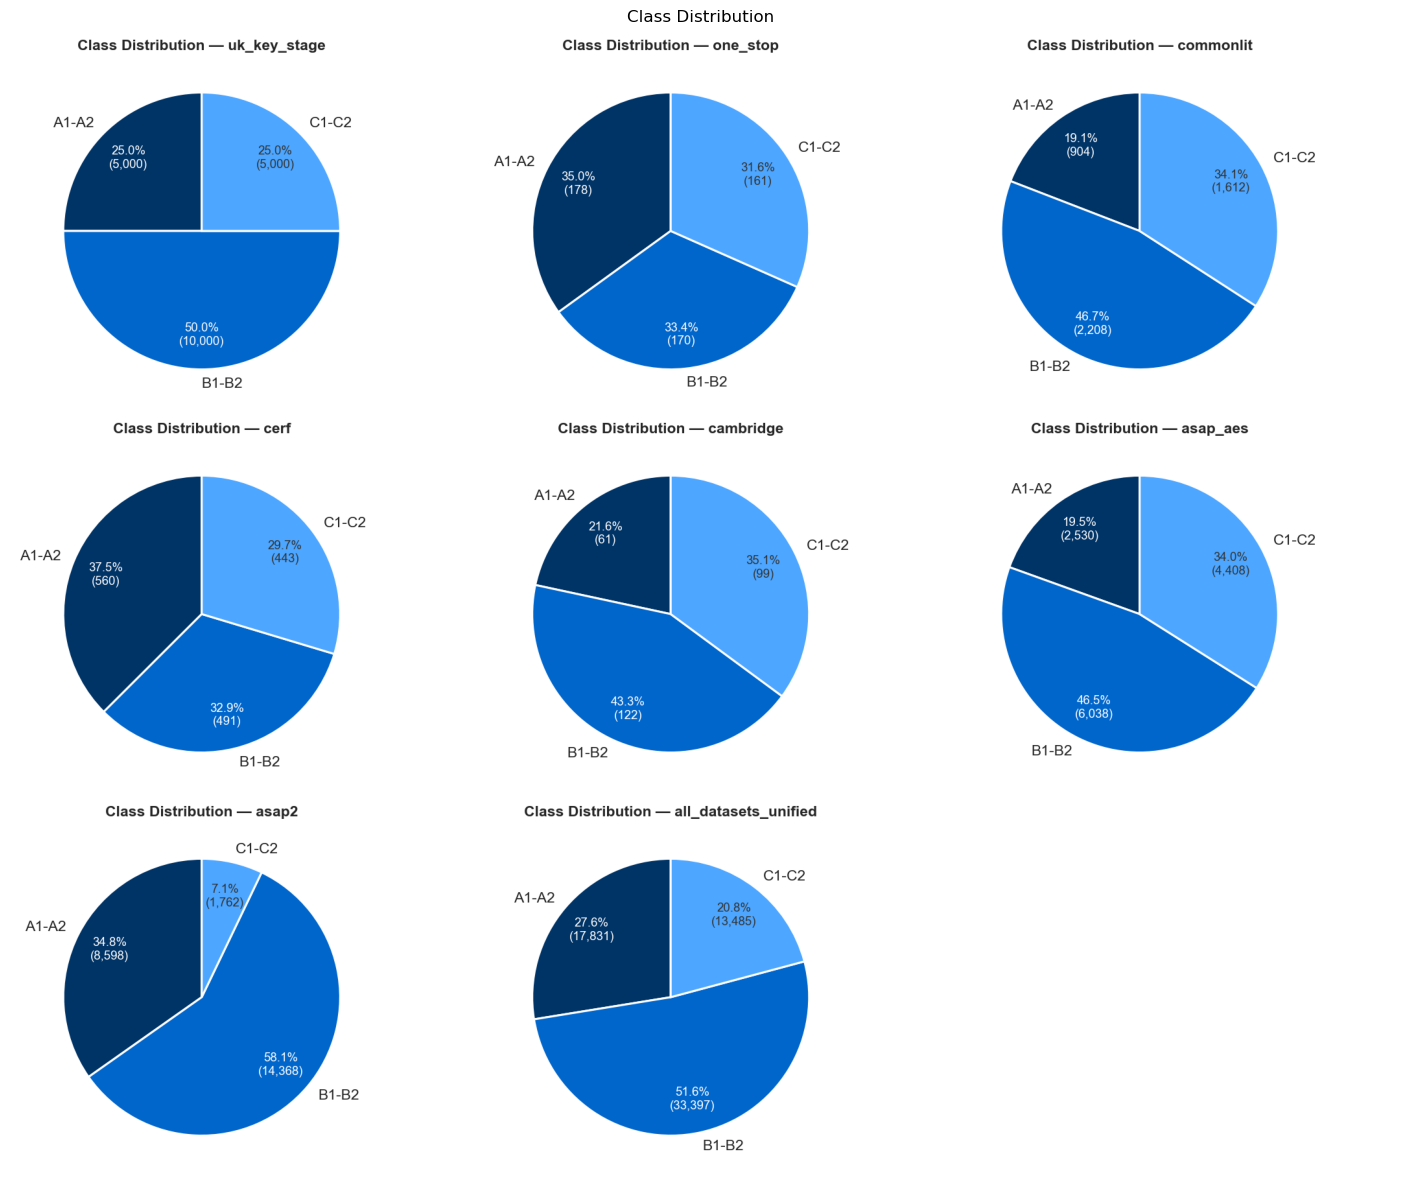

Displayed existing plot: outputs/eda/eda_class_distribution_pie.png


In [6]:
# ── 1.4 plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png"

if display_saved_plot(plot_path, title="Class Distribution", figsize=(15, 12)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for ax, (name, df) in zip(axes, list(datasets.items())+[('all_datasets_unified', all_datasets_unified)]):
        counts = df["label"].value_counts().reindex(CLASSES, fill_value=0)

        _, _, autotexts = ax.pie(
            counts.values,
            labels=CLASSES,
            colors=COLORS,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * counts.sum() / 100)):,})",
            startangle=90,
            pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )

        for i, t in enumerate(autotexts):
            t.set_fontsize(9)
            t.set_color("white" if COLORS[i] in ["#003366", "#0066CC"] else "#333333")

        ax.set_title(f"Class Distribution — {name}", fontsize=11, fontweight="bold")

    for ax in axes[len(datasets):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
# ── compute text length ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        df["text_len"] = df["text"].str.split().str.len()
    
    all_datasets_unified["text_len"] = all_datasets_unified["text"].str.split().str.len()

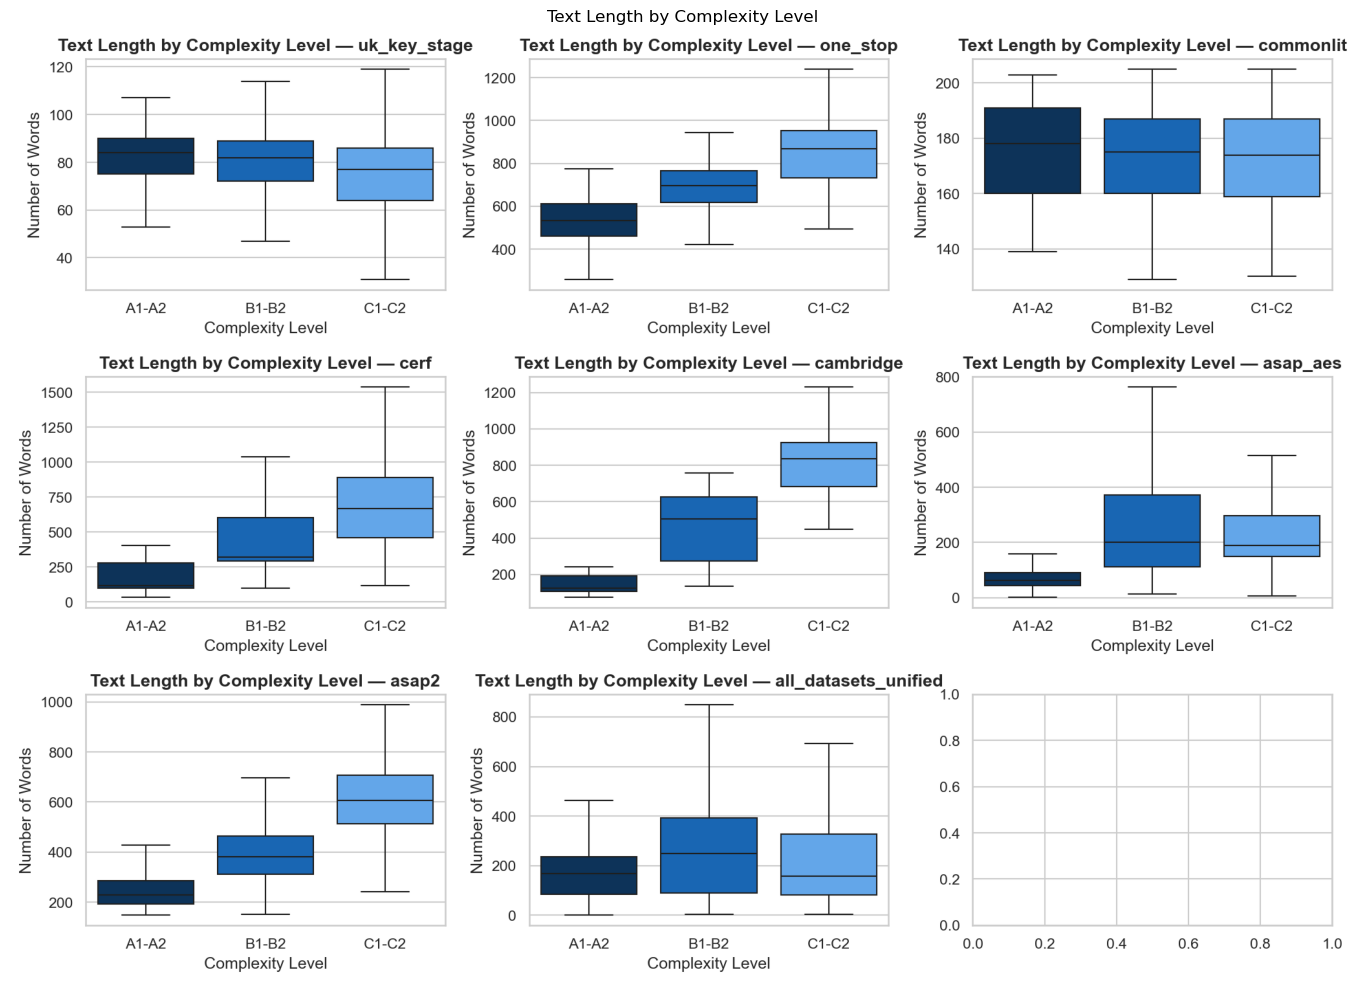

Displayed existing plot: outputs/eda/eda_text_length_by_class.png


In [8]:
# ── 1.5 plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"

if display_saved_plot(plot_path, title="Text Length by Complexity Level", figsize=(14, 10)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (name, df) in zip(axes, list(datasets.items()) + [('all_datasets_unified', all_datasets_unified)]):
        sns.boxplot(
            data=df,
            x="label",
            y="text_len",
            order=CLASSES,
            palette=COLORS,
            ax=ax,
            showfliers=False
        )
        ax.set_title(f"Text Length by Complexity Level — {name}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Complexity Level")
        ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

More difficul text seem to be longer.

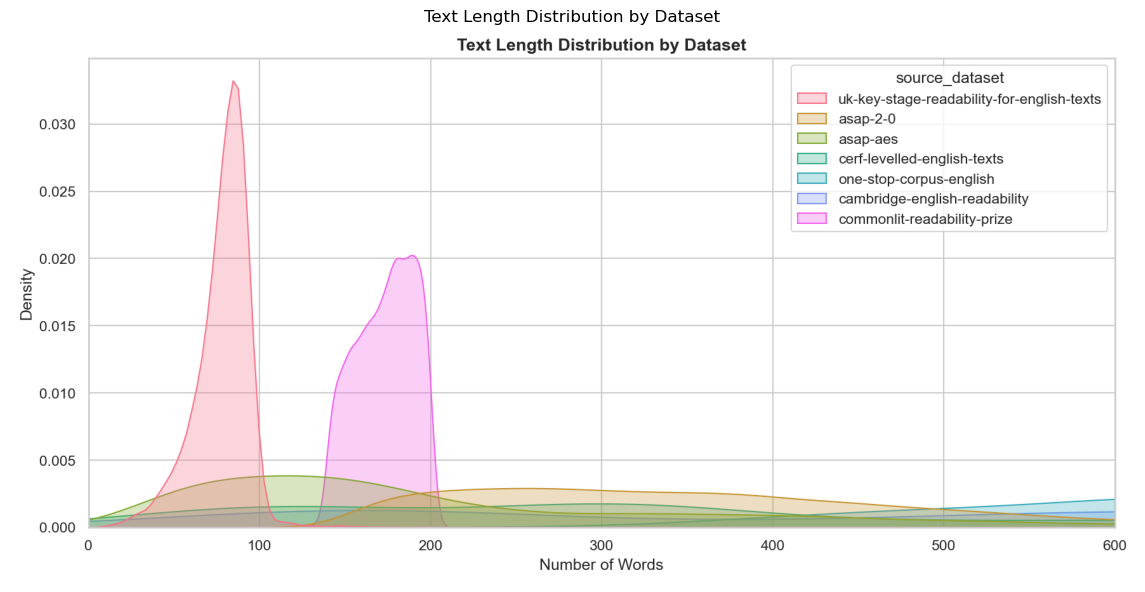

Displayed existing plot: outputs/eda/eda_length_distribution_by_dataset.png


In [9]:
# ── 1.6 plot_path = CFG["output_paths"]["eda"] / "eda_length_distribution_by_dataset.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_length_distribution_by_dataset.png"

if display_saved_plot(plot_path, title="Text Length Distribution by Dataset", figsize=(12, 6)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.kdeplot(
        data=all_datasets_unified,
        x="text_len",
        hue="source_dataset",
        fill=True,
        alpha=0.3,
        clip=(0, 600),
        common_norm=False,
        ax=ax
    )

    ax.set_title("Text Length Distribution by Dataset", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 600)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

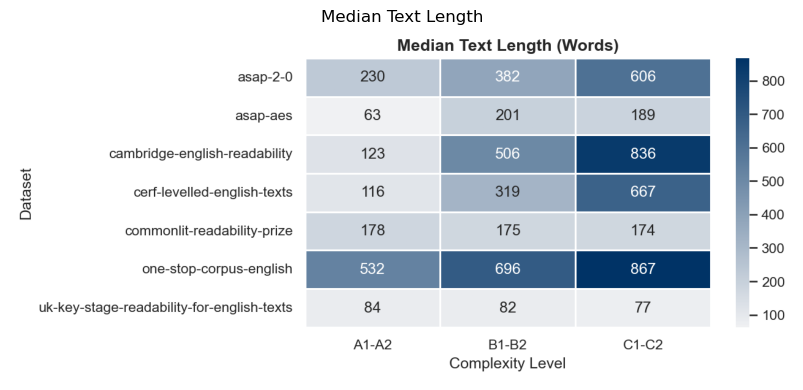

Displayed existing plot: outputs/eda/eda_median_length_heatmap.png


In [10]:
# ── 1.7 plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png"

if display_saved_plot(plot_path, title="Median Text Length", figsize=(9, 4)):
    print(f"Displayed existing plot: {plot_path}")
else:
    median_len = (
        all_datasets_unified
        .groupby(["source_dataset", "label"])["text_len"]
        .median()
        .unstack()
        .reindex(columns=CLASSES)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(
        median_len,
        annot=True,
        fmt=".0f",
        cmap=sns.light_palette(COLORS[0], as_cmap=True),
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title("Median Text Length (Words)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Complexity Level")
    ax.set_ylabel("Dataset")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

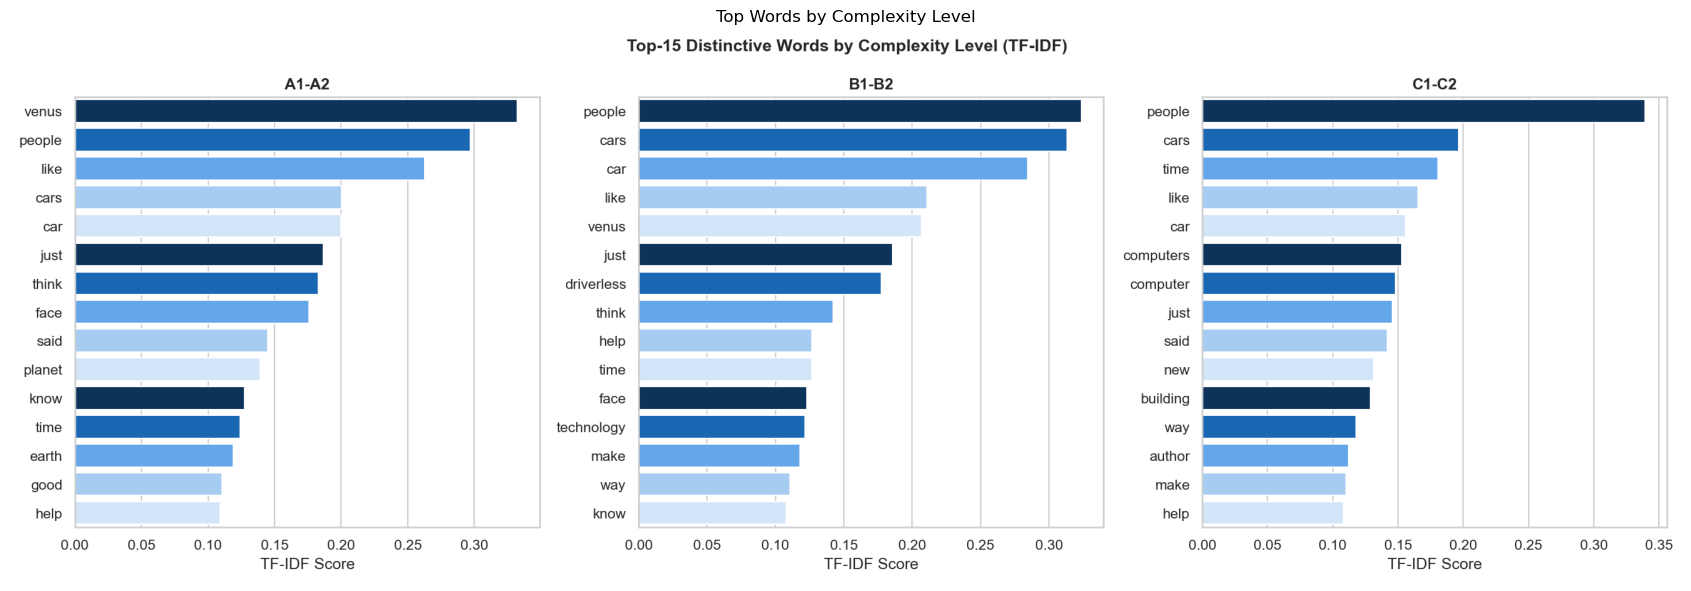

Displayed existing plot: outputs/eda/eda_top_words_tfidf.png


In [11]:
# ── 1.8 plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"

if display_saved_plot(plot_path, title="Top Words by Complexity Level", figsize=(18, 6)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 6))

    for ax, cls in zip(axes, CLASSES):
        top = get_top_words_tfidf(all_datasets_unified, cls)
        sns.barplot(data=top, y="word", x="score", ax=ax, palette=CONSULTING_COLORS[:len(top)])
        ax.set_title(cls, fontsize=12, fontweight="bold")
        ax.set_xlabel("TF-IDF Score")
        ax.set_ylabel("")

    fig.suptitle(
        "Top-15 Distinctive Words by Complexity Level (TF-IDF)",
        fontsize=13,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

<a id="section-1-1-results"></a>
## 1.1 Results

- The exploratory analysis showed that UK Key Stage and ASAP 2.0 are the largest datasets and together provide the majority of training samples. Therefore, these two datasets will form the main training pool.
- This pool will be divided into subsets for training, validation, and internal testing using readability class stratification.
- The remaining datasets will be reserved for external cross-dataset evaluation only.
- This setup allows us to assess both in-domain performance on similar data and generalization ability on unseen corpora.

---
<a id="section-2-data-preparation"></a>
# SECTION 2 — Data Preparation
We clean the text, align the labels, and prepare comparable splits.
We get reusable train, validation, and test sets for every model family, so the later scores stay directly comparable.


<a id="section-2-1-preprocessing-steps"></a>
## 2.1 Preprocessing Steps

In [12]:
# ── 2.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets.items():
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping preprocessing (CFG['run_data_prep']=False)")

Skipping preprocessing (CFG['run_data_prep']=False)


In [13]:
# ── 2.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")

Skipping dataset cleaning (CFG['run_data_prep']=False)


In [14]:
# ── 2.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}

utils_data.class2id = class2id
utils_models_loading.class2id = class2id
utils_models_inference.class2id = class2id


In [15]:
# ── 2.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        df["label_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding for datasets (CFG['run_data_prep']=False)")

Skipping label encoding for datasets (CFG['run_data_prep']=False)


<a id="section-2-2-train-val-test-split"></a>
## 2.2 Train/Val/Test Split

In [16]:
# ── 2.6 create training pool split ─────────────────────────────────────────
if CFG["run_data_prep"]:
    train_pool_keys = CFG.get("train_pool_datasets", ["uk_key_stage", "asap2"])
    missing_datasets = [name for name in train_pool_keys if name not in datasets]

    if missing_datasets:
        raise ValueError(f"Missing required datasets: {missing_datasets}")

    train_pool = (
        pd.concat([datasets[name].copy() for name in train_pool_keys], ignore_index=True)
        .sample(frac=1, random_state=CFG["seed"])
        .reset_index(drop=True)
    )

    required_cols = ["text_raw", "text_clean", CFG.get("encoded_label_col", "label_enc")]
    missing_cols = [c for c in required_cols if c not in train_pool.columns]
    if missing_cols:
        raise ValueError(f"train_pool: missing columns {missing_cols}")

    train_pool_target_col = resolve_target_col(train_pool, CFG)
    if train_pool_target_col not in train_pool.columns:
        raise ValueError(f"train_pool: missing target column {train_pool_target_col!r}.")

    splits = {
        CFG["train_pool_key"]: make_splits_and_arrays(train_pool, CFG)
    }

    train_pool_split = splits[CFG["train_pool_key"]]
    print(
        f"{CFG['train_pool_key']} ({' + '.join(train_pool_keys)}) -> "
        f"Train: {len(train_pool_split['df_train'])} | "
        f"Val: {len(train_pool_split['df_val'])} | Test: {len(train_pool_split['df_test'])}"
    )

    external_eval_keys = CFG.get("external_eval_dataset_keys")
    if external_eval_keys:
        missing_external = [name for name in external_eval_keys if name not in datasets]
        if missing_external:
            raise ValueError(f"Missing external evaluation datasets: {missing_external}")
    else:
        external_eval_keys = [name for name in datasets if name not in train_pool_keys]

    external_eval_datasets = {
        name: datasets[name].copy() for name in external_eval_keys
    }
    external_eval_summary_df = pd.DataFrame(
        [
            {
                "dataset": name,
                "rows": len(df),
                "classes": ', '.join(sorted(df[CFG["label_col"]].dropna().astype(str).unique().tolist())),
            }
            for name, df in external_eval_datasets.items()
        ]
    ).sort_values(["rows", "dataset"], ascending=[False, True]).reset_index(drop=True)

    print("\nExternal evaluation datasets:")
    display(external_eval_summary_df)

    cv = StratifiedKFold(
        n_splits=CFG["cv_folds"],
        shuffle=True,
        random_state=CFG["seed"]
    )
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")

Skipping split creation (CFG['run_data_prep']=False)


In [17]:
# ── 2.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    split_artifacts = {
        "splits": splits,
        "train_pool_sources": train_pool_keys,
        "external_eval_datasets": external_eval_datasets,
        "external_eval_summary_df": external_eval_summary_df,
    }

    with open(CFG["split_artifact_path"], "wb") as f:
        pickle.dump(split_artifacts, f)
else:
    print("Skipping split serialization (CFG['run_data_prep']=False)")

Skipping split serialization (CFG['run_data_prep']=False)


In [18]:
# ── 2.8 load split artifacts ─────────────────────────────────────────
split_artifacts = locals().get("split_artifacts")

if split_artifacts is None:
    try:
        split_artifacts = load_pickle_with_fallback(Path(CFG["split_artifact_path"]))
    except Exception as e_local:
        print(f"Local load failed: {e_local}")
        print("Trying to download split artifacts from Hugging Face...")

        hf_path = Path(hf_hub_download(
            repo_id="boblaros/complexity-splits",
            filename="complexity_splits.pkl",
            repo_type="dataset",
        ))

        split_artifacts = load_pickle_with_fallback(hf_path)

splits = split_artifacts["splits"]
train_pool_key = CFG.get("train_pool_key", "train_pool")
train_pool_split = splits[train_pool_key]
train_pool_sources = split_artifacts.get("train_pool_sources", CFG.get("train_pool_datasets", []))
external_eval_datasets = split_artifacts["external_eval_datasets"]
external_eval_summary_df = split_artifacts.get("external_eval_summary_df")
if external_eval_summary_df is None:
    external_eval_summary_df = pd.DataFrame(
        [
            {
                "dataset": name,
                "rows": len(df),
                "classes": ', '.join(sorted(df[CFG["label_col"]].dropna().astype(str).unique().tolist())),
            }
            for name, df in external_eval_datasets.items()
        ]
    ).sort_values(["rows", "dataset"], ascending=[False, True]).reset_index(drop=True)

external_eval_bundles = {
    name: build_transformer_eval_bundle_from_df(df, dataset_name=name)
    for name, df in external_eval_datasets.items()
}
display(external_eval_summary_df)

utils_data.splits = splits
utils_plots.external_eval_datasets = external_eval_datasets


Local load failed: Could not find pickle file. Tried: ['data/complexity_splits.pkl']
Trying to download split artifacts from Hugging Face...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/boblaros/complexity-splits/resolve/main/complexity_splits.pkl "HTTP/1.1 302 Found"


Loaded pickle: /Users/georgijkutivadze/.cache/huggingface/hub/datasets--boblaros--complexity-splits/snapshots/5d08cb62edafda1798b785ba4b6c3f83c7a0e3e8/complexity_splits.pkl
one_stop: eval=507
commonlit: eval=4,723
cerf: eval=1,493
cambridge: eval=274
asap_aes: eval=12,972


,dataset,rows,classes
0,asap_aes,12972,"A1-A2, B1-B2, C1-C2"
1,commonlit,4723,"A1-A2, B1-B2, C1-C2"
2,cerf,1493,"A1-A2, B1-B2, C1-C2"
3,one_stop,507,"A1-A2, B1-B2, C1-C2"
4,cambridge,274,"A1-A2, B1-B2, C1-C2"


---
<a id="section-3-baseline-models"></a>
# SECTION 3 — Baseline Models
We start with simple baselines to anchor the task.
We get learning curves and test metrics on the shared in-domain training pool split, and we can see the first gains before moving to heavier models.


Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  

<a id="section-3-1-preparation-architecture"></a>
## 3.1 Preparation & Architecture

In [19]:
le = DictLabelEncoder(class2id)

utils_metrics.le = le
utils_training.le = le

In [20]:
# -- 3.1 baseline_models = build_baseline_pipeline_models(CFG) ---------
baseline_models = build_baseline_pipeline_models(CFG)

best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"

if best_models_cache.exists() and tuning_cache.exists():
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")
else:
    best_baseline_models, baseline_tuning_df = tune_baselines_on_reference_split(
        models=baseline_models,
        split=train_pool_split,
        seed=CFG["seed"],
        n_iter=4,
    )
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df, tuning_cache)
    print(f"Best baseline selection completed on {train_pool_key} (validation split).")

le = DictLabelEncoder(class2id)
display(baseline_tuning_df)


Loaded cached baseline tuning artefacts -> skipping retuning.


,model,params,val_f1_macro,selected,note
0,Majority Class,fixed,NaN,True,kept fixed
1,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.630562,False,candidate
2,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.628270,False,candidate
3,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.645385,False,candidate
4,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.663830,False,candidate
5,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.663830,True,best_on_reference_val
6,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.645955,False,candidate
7,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.629648,False,candidate
8,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.671581,False,candidate
9,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.645955,False,candidate


<a id="section-3-2-training"></a>
## 3.2 Training

In [21]:
# -- 3.2 Train baseline models on the shared train-pool split ---------------
baseline_split_keys = [train_pool_key]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=baseline_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key=train_pool_key,
)

Baseline train/eval:   0%|          | 0/4 [00:00<?, ?it/s]

All baseline runs were restored from cache. Detailed per-model metric logs were suppressed.


,model,split_key,train_size,status,source,val_f1_macro,test_f1_macro
0,Majority Class,train_pool,"31,305",cached,baseline_eval_metrics.csv,0.235109,0.235109
1,TF-IDF + LogReg,train_pool,"31,305",cached,baseline_eval_metrics.csv,0.663830,0.660787
2,TF-IDF + SVC,train_pool,"31,305",cached,baseline_eval_metrics.csv,0.671581,0.668679
3,TF-IDF + XGBoost,train_pool,"31,305",cached,baseline_eval_metrics.csv,0.551168,0.534221


<a id="section-3-3-results"></a>
## 3.3 Results

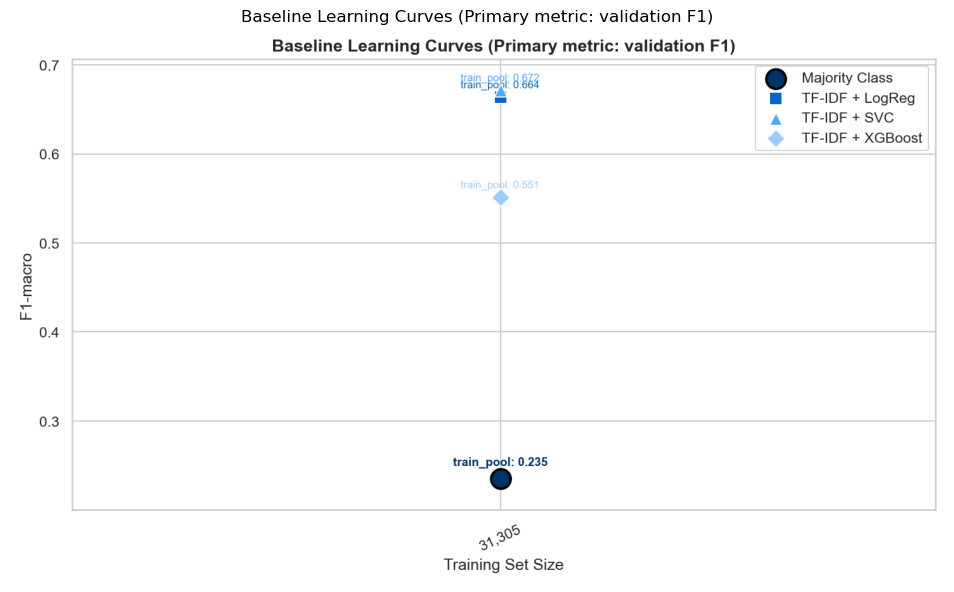

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


In [22]:
# -- 3.3 Baseline internal metrics and artefacts -----------------------------
plot_learning_curve_from_metrics(
    baseline_curve_df,
    title="Baseline Learning Curves (Primary metric: validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)

metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}


---
<a id="section-4-static-embeddings-models"></a>
# SECTION 4 — Static Embeddings + Models (FastText, MLP + CNN)
We move to fixed embeddings with lightweight neural models.
We get shared vocab and embedding artefacts plus MLP and CNN runs, and we can already check how much extra capacity helps once the data grow.


<a id="section-4-1-preparation-architecture"></a>
## 4.1 Preparation & Architecture
Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).


**Architecture:**
- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).  
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

In [23]:
# -- 4.1 Prepare shared vocabulary, embeddings, and loaders -----------------
complexity_split_keys_dl = [train_pool_key]
base_split_key_dl = train_pool_key

base_split = splits[base_split_key_dl]
X_train, X_val, X_test = base_split["X_train"], base_split["X_val"], base_split["X_test"]
X_train_raw, X_val_raw, X_test_raw = base_split["X_train_raw"], base_split["X_val_raw"], base_split["X_test_raw"]
y_train, y_val, y_test = base_split["y_train"], base_split["y_val"], base_split["y_test"]
df_train, df_val, df_test = base_split["df_train"], base_split["df_val"], base_split["df_test"]

print(
    f"{base_split_key_dl}: train={len(X_train):,} | "
    f"val={len(X_val):,} | test={len(X_test):,}"
)
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")

vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)
print(f"Vocabulary size: {len(vocab):,}")

vocab_words = set(vocab.keys())
total = 0
oov = 0
for text in X_val:
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)
if total:
    print(f"OOV rate: {oov / total:.2%}  ({oov}/{total})")

if CFG.get("dl_train_mode", True):
    embedding_matrix = load_embedding_matrix(
        vocab, CFG["embedding_model"], CFG["embedding_dim"]
    )
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
else:
    embedding_matrix = None
    print("Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.")

seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val = texts_to_sequences(X_val, vocab, CFG["max_seq_len"])
seq_test = texts_to_sequences(X_test, vocab, CFG["max_seq_len"])
print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"],
)
print("Base split DataLoaders ready.")

dl_split_data = {
    base_split_key_dl: {
        "loader_train": loader_train,
        "loader_val": loader_val,
        "loader_test": loader_test,
        "y_val": y_val,
        "y_test": y_test,
        "df_test": df_test,
        "train_size": len(X_train),
    }
}
print("Shared deep-learning split DataLoaders ready.")

CMAP = sns.light_palette(COLORS[0], as_cmap=True)

DEEP_MODEL_SPECS = build_deep_model_specs(
    vocab=vocab,
    embedding_matrix=embedding_matrix,
    cfg=CFG,
)

utils_metrics.shared_vocab = vocab


train_pool: train=31,305 | val=6,709 | test=6,709
Base split for shared vocabulary/embeddings: train_pool
Vocabulary size: 50,000
OOV rate: 4.96%  (41341/832998)
Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.
seq_train: (31305, 256) | seq_val: (6709, 256) | seq_test: (6709, 256)
Base split DataLoaders ready.
Shared deep-learning split DataLoaders ready.


<a id="section-4-2-training"></a>
## 4.2 Training
Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.



===== GloVe MLP | train_pool =====


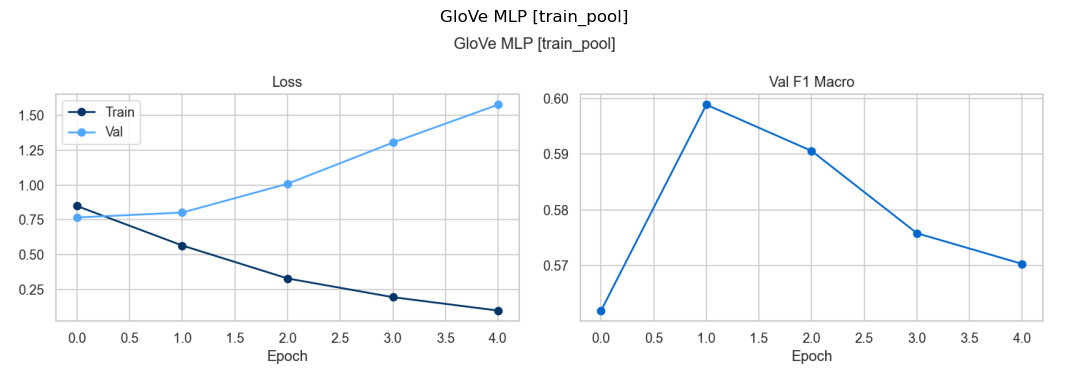

Displayed existing training curve: outputs/plots/histories/history_glove_mlp_train_pool.png
GloVe MLP [train_pool]: cached predictions not found -> metrics-only return
GloVe MLP [train_pool]: loaded cached metrics -> skip evaluation (models/glove_mlp_complexity_train_pool_20260307_163101/runs/metrics_latest.json)
GloVe MLP [train_pool] | VAL metrics: {'accuracy': 0.654941123863467, 'f1_macro': 0.5989057106653234, 'f1_weighted': 0.6457117995420596}
GloVe MLP [train_pool] | TEST metrics: {'accuracy': 0.6527053212103145, 'f1_macro': 0.5964460940300637, 'f1_weighted': 0.6426749637907794}
Final validation F1 (macro) [GloVe MLP [train_pool]]: 0.5989 (cached)


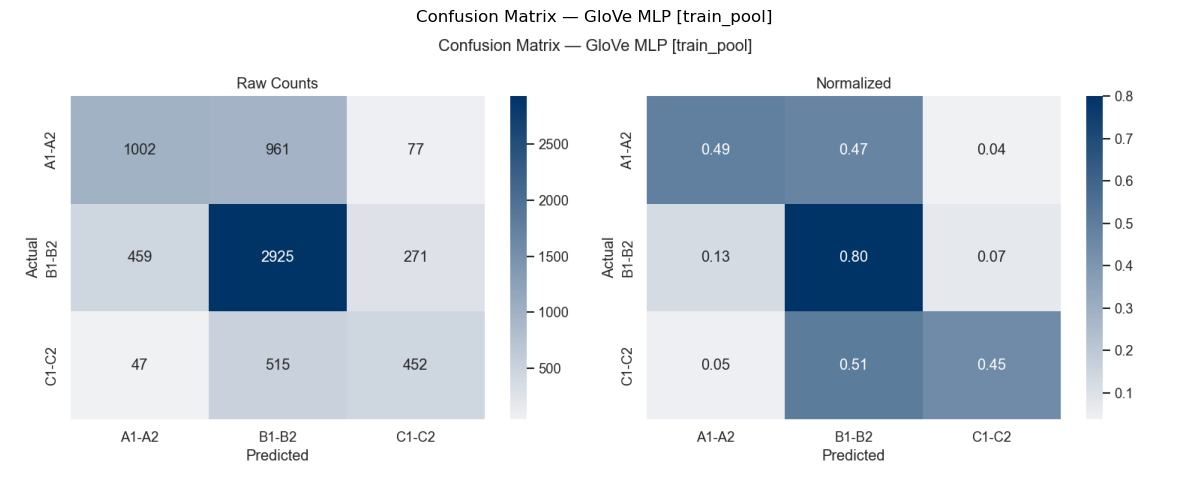

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_train_pool.png

===== GloVe CNN | train_pool =====


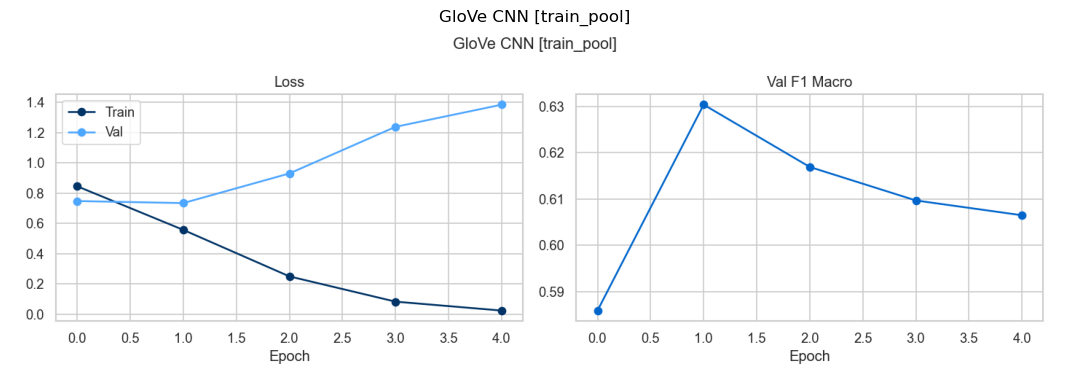

Displayed existing training curve: outputs/plots/histories/history_glove_cnn_train_pool.png
GloVe CNN [train_pool]: cached predictions not found -> metrics-only return
GloVe CNN [train_pool]: loaded cached metrics -> skip evaluation (models/glove_cnn_complexity_train_pool_20260307_163151/runs/metrics_latest.json)
GloVe CNN [train_pool] | VAL metrics: {'accuracy': 0.6744671337009986, 'f1_macro': 0.6303509816605484, 'f1_weighted': 0.6712168813094422}
GloVe CNN [train_pool] | TEST metrics: {'accuracy': 0.6795349530481443, 'f1_macro': 0.6388266463257223, 'f1_weighted': 0.6766999349479854}
Final validation F1 (macro) [GloVe CNN [train_pool]]: 0.6304 (cached)


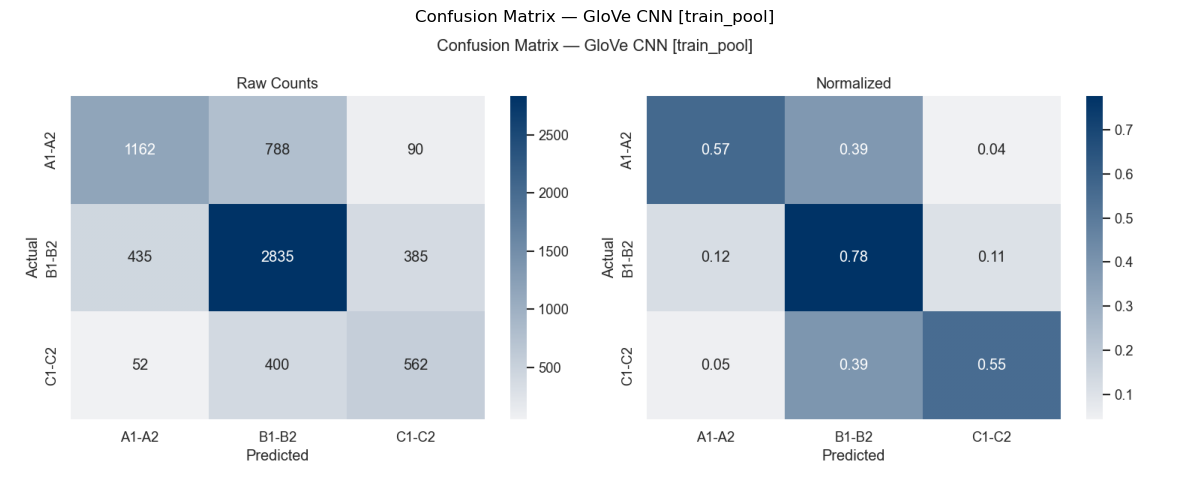

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_cnn_train_pool.png


In [24]:
# -- 4.2 Train GloVe MLP and GloVe CNN on the shared split ------------------
deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}
DEEP_RUNS = {}

for model_label in ["GloVe MLP", "GloVe CNN"]:
    print()
    print(f"===== {model_label} | {train_pool_key} =====")
    split_data = dl_split_data[train_pool_key]
    model_spec = DEEP_MODEL_SPECS[model_label]

    model_obj, history, val_metrics, test_metrics, test_preds = run_torch_experiment(
        model_label=model_label,
        family_slug=model_spec["family_slug"],
        split_key=train_pool_key,
        split_data=split_data,
        model_builder=model_spec["builder"],
        label_encoder=le,
    )

    exp_paths = resolve_experiment_paths(
        model_family=model_spec["family_slug"],
        dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
        size_tag=size_tag_from_split(train_pool_key),
        model_root=CFG["model_dir"],
    )

    run_name = f"{model_label} [{train_pool_key}]"
    deep_histories[run_name] = history
    deep_test_preds[run_name] = test_preds
    DEEP_RUNS[model_label] = {
        "model": model_obj,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "test_preds": test_preds,
        "best_checkpoint": str(exp_paths["best_model"] / "best.pt"),
    }

    deep_curve_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    plot_confusion_matrix_clf(split_data["y_test"], test_preds, run_name, le)


<a id="section-4-3-results"></a>
## 4.3 Results

---
<a id="section-5-recurrent-model-bilstm"></a>
# SECTION 5 — Recurrent Model (BiLSTM)
We add a recurrent model on the same setup.
We get BiLSTM results on the matched splits, and we can judge whether sequence modelling is worth the extra complexity here.


<a id="section-5-1-preparation-architecture"></a>
## 5.1 Preparation & Architecture
**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


<a id="section-5-2-training"></a>
## 5.2 Training


===== GloVe BiLSTM | train_pool =====


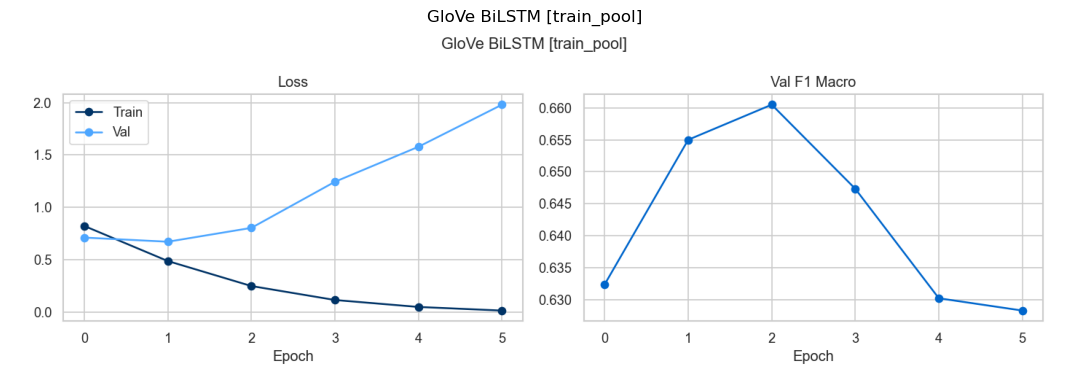

Displayed existing training curve: outputs/plots/histories/history_glove_bilstm_train_pool.png
GloVe BiLSTM [train_pool]: cached predictions not found -> metrics-only return
GloVe BiLSTM [train_pool]: loaded cached metrics -> skip evaluation (models/glove_bilstm_complexity_train_pool_20260307_163358/runs/metrics_latest.json)
GloVe BiLSTM [train_pool] | VAL metrics: {'accuracy': 0.682963183782978, 'f1_macro': 0.6450992102932628, 'f1_weighted': 0.6830474215229027}
GloVe BiLSTM [train_pool] | TEST metrics: {'accuracy': 0.6926516619466389, 'f1_macro': 0.6551661294897166, 'f1_weighted': 0.6923209903034657}
Final validation F1 (macro) [GloVe BiLSTM [train_pool]]: 0.6451 (cached)


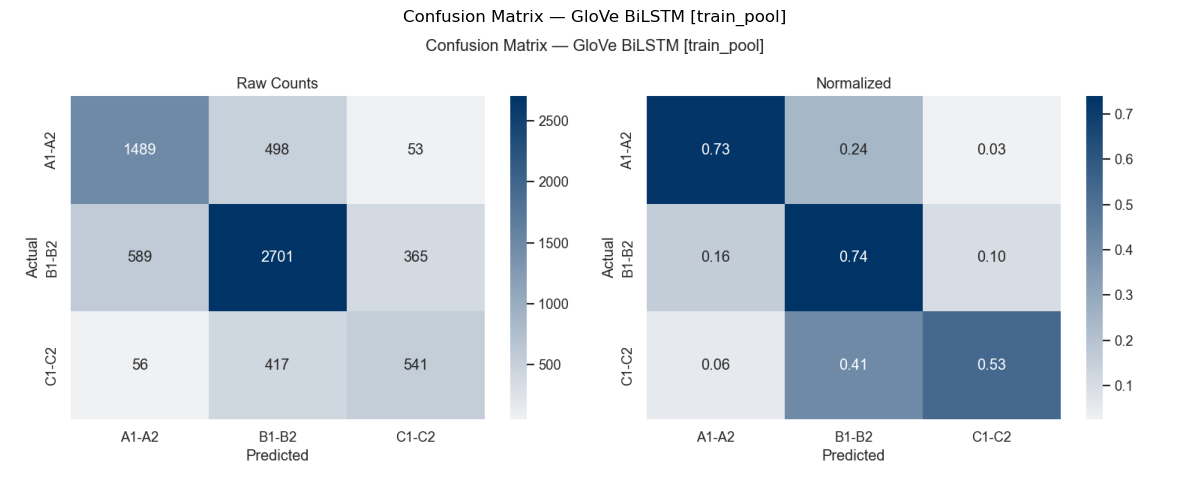

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_bilstm_train_pool.png


In [25]:
# -- 5.2 Train GloVe BiLSTM on the shared split -----------------------------
print()
print(f"===== GloVe BiLSTM | {train_pool_key} =====")
split_data = dl_split_data[train_pool_key]
model_spec = DEEP_MODEL_SPECS["GloVe BiLSTM"]

bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
    model_label="GloVe BiLSTM",
    family_slug=model_spec["family_slug"],
    split_key=train_pool_key,
    split_data=split_data,
    model_builder=model_spec["builder"],
    label_encoder=le,
)

exp_paths = resolve_experiment_paths(
    model_family=model_spec["family_slug"],
    dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
    size_tag=size_tag_from_split(train_pool_key),
    model_root=CFG["model_dir"],
)

run_name = f"GloVe BiLSTM [{train_pool_key}]"
deep_histories[run_name] = lstm_history
deep_test_preds[run_name] = bilstm_preds
DEEP_RUNS["GloVe BiLSTM"] = {
    "model": bilstm_model,
    "history": lstm_history,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "test_preds": bilstm_preds,
    "best_checkpoint": str(exp_paths["best_model"] / "best.pt"),
}

deep_curve_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "f1_macro": float(val_metrics["f1_macro"]),
})

deep_eval_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "split": "val",
    "accuracy": float(val_metrics.get("accuracy", np.nan)),
    "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
    "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
})
deep_eval_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "split": "test",
    "accuracy": float(test_metrics.get("accuracy", np.nan)),
    "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
    "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
})

plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)


<a id="section-5-3-results"></a>
## 5.3 Results

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,train_pool,31305,0.645099
1,GloVe CNN,train_pool,31305,0.630351
2,GloVe MLP,train_pool,31305,0.598906


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,train_pool,31305,val,0.682963,0.645099,0.683047,NaN,GloVe BiLSTM [train_pool] | val
1,GloVe CNN,train_pool,31305,val,0.674467,0.630351,0.671217,NaN,GloVe CNN [train_pool] | val
2,GloVe MLP,train_pool,31305,val,0.654941,0.598906,0.645712,NaN,GloVe MLP [train_pool] | val


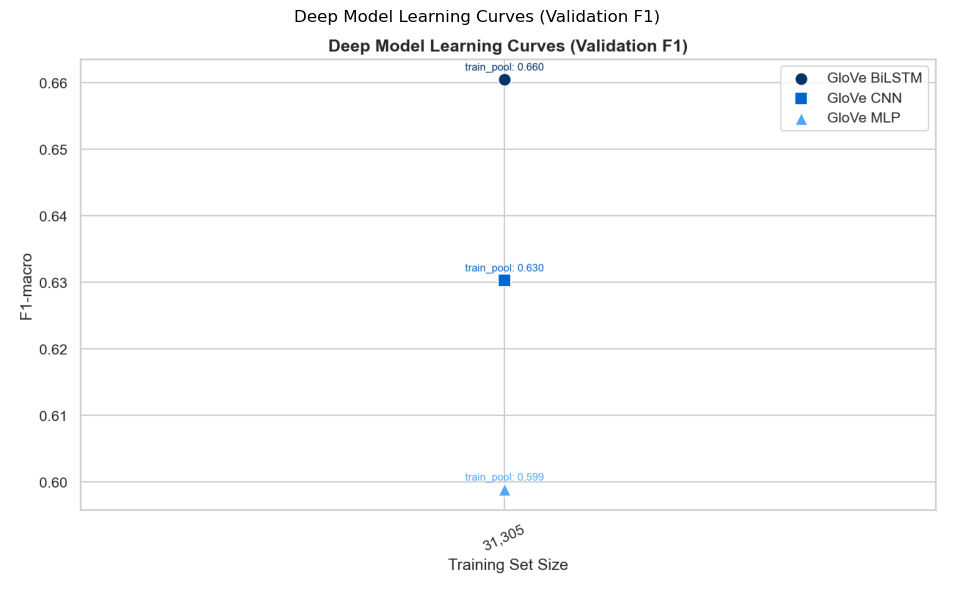

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,train_pool,31305,test,0.692652,0.655166,0.692321,NaN,GloVe BiLSTM [train_pool] | test
1,GloVe BiLSTM,train_pool,31305,val,0.682963,0.645099,0.683047,NaN,GloVe BiLSTM [train_pool] | val
2,GloVe CNN,train_pool,31305,test,0.679535,0.638827,0.676700,NaN,GloVe CNN [train_pool] | test
3,GloVe CNN,train_pool,31305,val,0.674467,0.630351,0.671217,NaN,GloVe CNN [train_pool] | val
4,GloVe MLP,train_pool,31305,test,0.652705,0.596446,0.642675,NaN,GloVe MLP [train_pool] | test
5,GloVe MLP,train_pool,31305,val,0.654941,0.598906,0.645712,NaN,GloVe MLP [train_pool] | val


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,train_pool,31305,0.645099
1,GloVe CNN,train_pool,31305,0.630351
2,GloVe MLP,train_pool,31305,0.598906
3,Majority Class,train_pool,31305,0.235109
4,TF-IDF + LogReg,train_pool,31305,0.663830
5,TF-IDF + SVC,train_pool,31305,0.671581
6,TF-IDF + XGBoost,train_pool,31305,0.551168


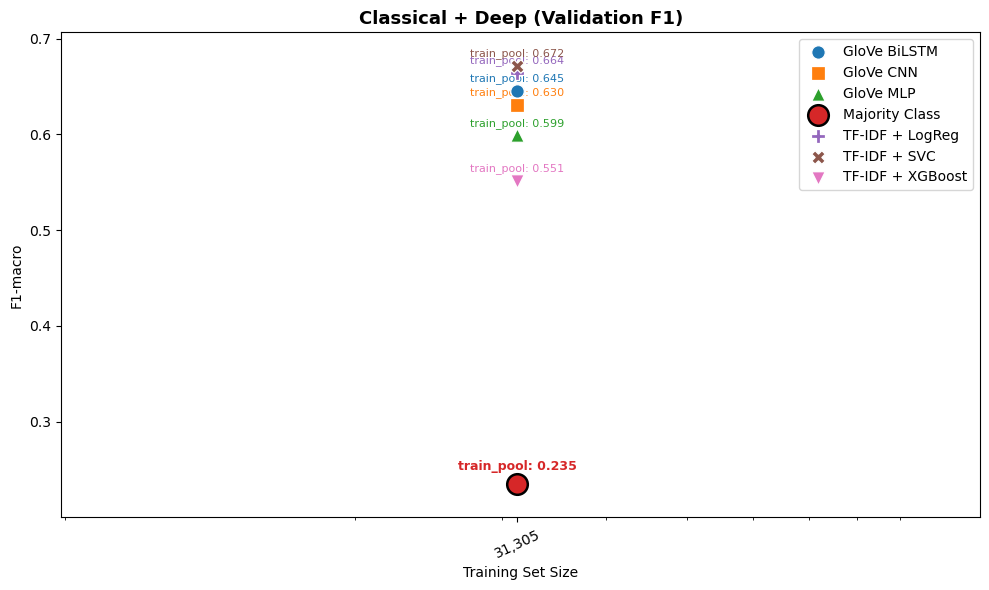

In [26]:
# -- 5.3 Summarize deep-model internal metrics and unified curves -----------
deep_curve_df, deep_val_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)

deep_test_eval_df = collect_deep_eval_from_results(
    results=RESULTS,
    splits=splits,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="test",
)

deep_internal_eval_df = (
    pd.concat([deep_val_eval_df, deep_test_eval_df], ignore_index=True)
    .sort_values(["model", "split", "train_size"])
    .reset_index(drop=True)
)
display(deep_internal_eval_df)

metrics_dir = CFG["output_paths"]["metrics"]
deep_curve_df.to_csv(metrics_dir / "deep_curve_metrics.csv", index=False)
joblib.dump(deep_curve_df, metrics_dir / "deep_curve_metrics.pkl")

deep_val_eval_df.to_csv(metrics_dir / "deep_eval_metrics_val.csv", index=False)
joblib.dump(deep_val_eval_df, metrics_dir / "deep_eval_metrics_val.pkl")

deep_test_eval_df.to_csv(metrics_dir / "deep_eval_metrics_test.csv", index=False)
joblib.dump(deep_test_eval_df, metrics_dir / "deep_eval_metrics_test.pkl")

deep_internal_eval_df.to_csv(metrics_dir / "deep_eval_metrics_internal.csv", index=False)
joblib.dump(deep_internal_eval_df, metrics_dir / "deep_eval_metrics_internal.pkl")

if deep_curve_df is not None and not deep_curve_df.empty:
    classical_part = baseline_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()

    combined_curve_df = (
        pd.concat([classical_part, deep_part], ignore_index=True)
        .drop_duplicates(subset=["model", "split_key"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )

    display(combined_curve_df)
    plot_learning_curve_from_metrics(
        combined_curve_df,
        title="Classical + Deep (Validation F1)",
        save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
        force_replot=True,
    )

    combined_curve_df.to_csv(metrics_dir / "combined_curve_metrics.csv", index=False)
    joblib.dump(combined_curve_df, metrics_dir / "combined_curve_metrics.pkl")
else:
    combined_curve_df = pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])


---
<a id="section-6-transformer-fine-tuning"></a>
# SECTION 6 — Transformer Fine-Tuning
We fine-tune pretrained transformers as our strongest in-domain candidates.
We get validation and test summaries for DistilBERT and RoBERTa, and we can pick the best checkpoint for the next transfer checks.


<a id="section-6-1-preparation-architecture"></a>
## 6.1 Preparation & Architecture

**Architecture:**
- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.
- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.


In [27]:
# -- 6.1 Prepare transformer bundles and experiment registry ----------------
TRANSFORMER_RUNS = {}
BASE_TRAIN_POOL_BUNDLE = build_transformer_bundle_from_split(train_pool_key)
TRANSFORMER_SIZE_TAG = size_tag_from_split(train_pool_key)

TRANSFORMER_PLAN = pd.DataFrame([
    {
        "experiment": "DistilBERT_train_pool",
        "model_name": "distilbert-base-uncased",
        "batch_size": CFG["batch_size"],
        "epochs": CFG["epochs"],
        "lr": CFG["lr"],
    },
    {
        "experiment": "RoBERTa_train_pool",
        "model_name": "roberta-base",
        "batch_size": min(CFG["batch_size"], 8),
        "epochs": CFG["epochs"],
        "lr": 2e-5,
    },
    {
        "experiment": "DeBERTaV3_train_pool",
        "model_name": "microsoft/deberta-v3-base",
        "batch_size": 2,
        "epochs": 4,
        "lr": 2e-5,
    },
])
display(TRANSFORMER_PLAN)

,experiment,model_name,batch_size,epochs,lr
0,DistilBERT_train_pool,distilbert-base-uncased,8,3,0.00002
1,RoBERTa_train_pool,roberta-base,8,3,0.00002
2,DeBERTaV3_train_pool,microsoft/deberta-v3-base,2,4,0.00002


<a id="section-6-2-training"></a>
## 6.2 Training

<a id="section-6-2-1-reference-distilbert"></a>
### 6.2.1 Reference DistilBERT

In [28]:
# -- 6.2.1 Reference DistilBERT ---------------------------------------------
print("\n### 7.2.1 Reference DistilBERT ###")

TRANSFORMER_RUNS["DistilBERT_train_pool"] = run_transformer_experiment(
    display_name="DistilBERT_train_pool",
    family_slug="distilbert",
    size_tag=TRANSFORMER_SIZE_TAG,
    model_name="distilbert-base-uncased",
    data_bundle=BASE_TRAIN_POOL_BUNDLE,
    batch_size=CFG["batch_size"],
    epochs=CFG["epochs"],
    lr=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    early_stopping_patience=2,
    eval_mode="epoch",
)


### 7.2.1 Reference DistilBERT ###
DistilBERT_train_pool: loaded cached predictions -> val_preds_latest.npy, test_preds_latest.npy
DistilBERT_train_pool: loaded cached metrics -> skip evaluation (models/distilbert_complexity_train_pool_20260307_164409/runs/metrics_latest.json)
DistilBERT_train_pool | VAL metrics: {'accuracy': 0.7677746310925623, 'f1_macro': 0.7371779636790571, 'f1_weighted': 0.7648968334776791}
DistilBERT_train_pool | TEST metrics: {'accuracy': 0.7746310925622298, 'f1_macro': 0.7430667400906253, 'f1_weighted': 0.7720896637566615}
Final validation F1 (macro) [DistilBERT_train_pool]: 0.7372 (cached)


<a id="section-6-2-2-alternative-roberta"></a>
### 6.2.2 Alternative RoBERTa

In [29]:
# -- 6.2.2 Alternative RoBERTa ----------------------------------------------
print("\n### 7.2.2 Alternative RoBERTa ###")

TRANSFORMER_RUNS["RoBERTa_train_pool"] = run_transformer_experiment(
    display_name="RoBERTa_train_pool",
    family_slug="roberta_base",
    size_tag=TRANSFORMER_SIZE_TAG,
    model_name="roberta-base",
    data_bundle=BASE_TRAIN_POOL_BUNDLE,
    batch_size=min(CFG["batch_size"], 8),
    epochs=CFG["epochs"],
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
)



### 7.2.2 Alternative RoBERTa ###
RoBERTa_train_pool: loaded cached predictions -> val_preds_latest.npy, test_preds_latest.npy
RoBERTa_train_pool: loaded cached metrics -> skip evaluation (models/roberta_base_complexity_train_pool_20260307_162036/runs/metrics_latest.json)
RoBERTa_train_pool | VAL metrics: {'accuracy': 0.7655388284394098, 'f1_macro': 0.7330615540945518, 'f1_weighted': 0.7626462251487529}
RoBERTa_train_pool | TEST metrics: {'accuracy': 0.7676255775823521, 'f1_macro': 0.7297663021875974, 'f1_weighted': 0.7644717465447768}
Final validation F1 (macro) [RoBERTa_train_pool]: 0.7331 (cached)


<a id="section-6-2-3-deberta-v3-base"></a>
### 6.2.3 DeBERTa-v3-base


### 7.2.3 DeBERTa-v3-base ###
DeBERTaV3_train_pool: loaded cached metrics/predictions -> skip evaluation


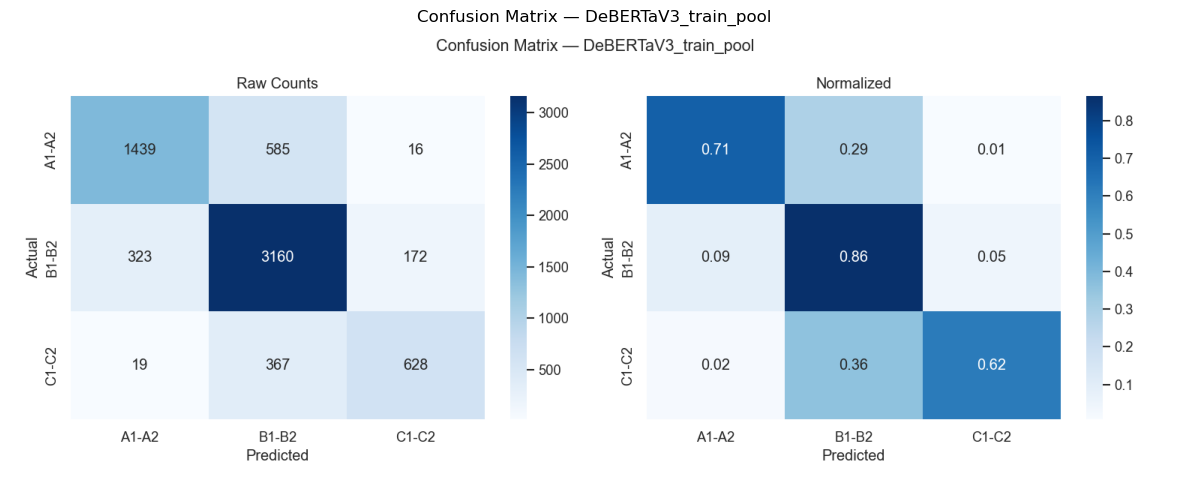

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool.png
DeBERTa resume summary: {'checkpoint_path': 'models/deberta_v3_base_complexity_train_pool_20260307_174910/checkpoints/checkpoint_epoch_4', 'start_epoch': 5, 'target_epochs': 4, 'epoch_5_completed': True, 'exact_resume_possible': False}
Exact replay limitations: python random state was not saved, numpy random state was not saved, torch random state was not saved, dataloader shuffle state was not saved


In [30]:
# -- 6.2.3 DeBERTa-v3-base ---------------------------------------------
import math

from transformers import get_cosine_schedule_with_warmup

print("\n### 7.2.3 DeBERTa-v3-base ###")

DEBERTA_DISPLAY_NAME = "DeBERTaV3_train_pool"
DEBERTA_MODEL_NAME = "microsoft/deberta-v3-base"
DEBERTA_FAMILY_SLUG = "deberta_v3_base"
DEBERTA_METRICS_STEM = "deberta_v3_base_train_pool"
DEBERTA_TOTAL_EPOCHS = 4
DEBERTA_BATCH_SIZE = 2
DEBERTA_GRAD_ACCUM_STEPS = 2

debarta_mode = CFG.get("deberta_execution_mode", "legacy_eval")
debarta_exp_paths = resolve_experiment_paths(
    model_family=DEBERTA_FAMILY_SLUG,
    dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
    size_tag=TRANSFORMER_SIZE_TAG,
    model_root=CFG["model_dir"],
)
debarta_metrics_dir = CFG["output_paths"]["metrics"] / "transformers"
debarta_metrics_dir.mkdir(parents=True, exist_ok=True)

debarta_cached_payload = _deberta_load_saved_payload(BASE_TRAIN_POOL_BUNDLE, debarta_exp_paths)
debarta_model_source = _deberta_resolve_model_source(debarta_exp_paths)
debarta_payload = None

if not CFG.get("run_transformer_eval", True):
    if debarta_cached_payload is not None and _deberta_has_full_cached_outputs(debarta_cached_payload, BASE_TRAIN_POOL_BUNDLE):
        debarta_payload = debarta_cached_payload
        print(f"{DEBERTA_DISPLAY_NAME}: loaded cached metrics/predictions -> skip evaluation")
    elif debarta_cached_payload is not None and debarta_model_source is None:
        # Downstream summary/error-analysis cells can still reuse saved metrics even if a model artifact is gone.
        debarta_payload = debarta_cached_payload
        print(f"{DEBERTA_DISPLAY_NAME}: cached metrics found but reusable model/checkpoint is missing -> using metrics-only payload")
    elif debarta_cached_payload is not None:
        # Partial cache is repaired by evaluating the saved artifact once so later sections get fresh preds.
        print(f"{DEBERTA_DISPLAY_NAME}: cached metrics found but predictions are incomplete -> evaluating saved artifact")
    else:
        print(f"{DEBERTA_DISPLAY_NAME}: cached artifacts not found -> evaluating reusable artifact or training if needed")
else:
    if debarta_model_source is not None:
        print(f"{DEBERTA_DISPLAY_NAME}: run_transformer_eval=True -> evaluating saved artifact from {debarta_model_source}")
    else:
        print(f"{DEBERTA_DISPLAY_NAME}: run_transformer_eval=True -> no reusable artifact found, training before evaluation")

if debarta_payload is None:
    debarta_legacy_best_dirs = [Path(debarta_exp_paths["root"]) / "archive" / "best_model"]
    latest_debarta_ckpt = _deberta_latest_checkpoint_dir(debarta_exp_paths["checkpoints"])
    if latest_debarta_ckpt is not None:
        debarta_legacy_best_dirs.append(latest_debarta_ckpt)

    if debarta_mode == "trainer":
        debarta_payload = run_transformer_experiment(
            display_name=DEBERTA_DISPLAY_NAME,
            family_slug=DEBERTA_FAMILY_SLUG,
            size_tag=TRANSFORMER_SIZE_TAG,
            model_name=DEBERTA_MODEL_NAME,
            data_bundle=BASE_TRAIN_POOL_BUNDLE,
            batch_size=DEBERTA_BATCH_SIZE,
            epochs=DEBERTA_TOTAL_EPOCHS,
            lr=2e-5,
            warmup_ratio=0.1,
            weight_decay=0.01,
            gradient_accumulation_steps=DEBERTA_GRAD_ACCUM_STEPS,
            early_stopping_patience=2,
            eval_mode="epoch",
            legacy_best_dirs=tuple(debarta_legacy_best_dirs),
        )
    else:
        debarta_payload = _run_deberta_notebook_experiment(
            display_name=DEBERTA_DISPLAY_NAME,
            exp_paths=debarta_exp_paths,
            data_bundle=BASE_TRAIN_POOL_BUNDLE,
            label_names=list(getattr(le, "classes_", CLASSES)),
            epochs=DEBERTA_TOTAL_EPOCHS,
            batch_size=DEBERTA_BATCH_SIZE,
            grad_accum_steps=DEBERTA_GRAD_ACCUM_STEPS,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,
            max_grad_norm=1.0,
            max_length=CFG["max_len"],
            fp16=(CFG["device"] == "cuda"),
            save_every_n_epochs=1,
            keep_last_n_ckpts=2,
            seed=CFG["seed"],
            model_name=DEBERTA_MODEL_NAME,
            device=CFG["device"],
            metrics_stem=DEBERTA_METRICS_STEM,
            transformer_metrics_dir=debarta_metrics_dir,
        )

TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME] = debarta_payload

register_results_metrics(
    DEBERTA_DISPLAY_NAME,
    "val",
    TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("val_metrics", {}),
)
register_results_metrics(
    DEBERTA_DISPLAY_NAME,
    "test",
    TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("test_metrics", {}),
)

history_plot_payload = TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("history_plot", {})
if isinstance(history_plot_payload, dict) and any(len(history_plot_payload.get(k, [])) for k in history_plot_payload):
    plot_history(history_plot_payload, DEBERTA_DISPLAY_NAME)

y_test_arr = np.asarray(TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("y_test", []), dtype=np.int64)
test_preds_arr = np.asarray(TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("test_preds", []), dtype=np.int64)
if len(y_test_arr) == len(test_preds_arr) and len(y_test_arr) > 0:
    plot_confusion_matrix_clf(
        y_test_arr,
        test_preds_arr,
        DEBERTA_DISPLAY_NAME,
        le,
    )

resume_info = TRANSFORMER_RUNS[DEBERTA_DISPLAY_NAME].get("resume_info", {})
if resume_info:
    print(
        "DeBERTa resume summary:",
        {
            "checkpoint_path": resume_info.get("checkpoint_path"),
            "start_epoch": resume_info.get("start_epoch"),
            "target_epochs": resume_info.get("target_epochs"),
            "epoch_5_completed": resume_info.get("epoch_5_completed"),
            "exact_resume_possible": resume_info.get("exact_resume_possible"),
        },
    )
    if resume_info.get("exact_resume_limitations"):
        print(
            "Exact replay limitations:",
            ", ".join(resume_info["exact_resume_limitations"]),
        )

utils_tasks_complexity.debarta_metrics_dir = debarta_metrics_dir


<a id="section-6-3-results"></a>
## 6.3 Results

In [31]:
# -- 6.2.3 Results -----------------------------------------------------
in_memory_transformer_summary_df = transformer_summary_from_runs(
    TRANSFORMER_RUNS if "TRANSFORMER_RUNS" in globals() else {}
)
saved_transformer_summary_df = load_saved_transformer_summary(CFG)

transformer_summary_df = merge_transformer_summary_frames(
    in_memory_transformer_summary_df,
    saved_transformer_summary_df,
)

globals()["transformer_summary_df"] = transformer_summary_df.copy()

if not transformer_summary_df.empty:
    display(transformer_summary_df.round(4))
    transformer_summary_df.to_csv(
        CFG["output_paths"]["metrics"] / "transformer_summary_metrics.csv",
        index=False,
    )

    best_row = transformer_summary_df.iloc[0]
    FINAL_TRANSFORMER_NAME = str(best_row["experiment"])
    TRANSFORMER_FINAL_BEST_PATH = Path(best_row["best_model"])

    best_payload = (TRANSFORMER_RUNS.get(FINAL_TRANSFORMER_NAME) if "TRANSFORMER_RUNS" in globals() else None)
    if isinstance(best_payload, dict) and len(np.asarray(best_payload.get("test_preds", []))) == len(np.asarray(best_payload.get("y_test", []))):
        trf_df_test = best_payload["df_test"].copy().reset_index(drop=True)
        trf_y_test = np.asarray(best_payload["y_test"], dtype=np.int64)
        trf_test_preds = np.asarray(best_payload["test_preds"], dtype=np.int64)
    else:
        restore_final_transformer_test_artifacts(CFG)

    print(
        f"Selected final transformer: {FINAL_TRANSFORMER_NAME} | "
        f"val_f1={best_row['val_f1_macro']:.4f} | test_f1={best_row['test_f1_macro']:.4f}"
    )
else:
    transformer_summary_df = pd.DataFrame(columns=TRANSFORMER_SUMMARY_COLUMNS)
    print("No transformer runs available.")



,experiment,val_f1_macro,test_f1_macro,val_accuracy,test_accuracy,best_model,experiment_dir
0,DeBERTaV3_train_pool,0.7473,0.7511,0.7758,0.7791,models/deberta_v3_base_complexity_train_pool_2...,models/deberta_v3_base_complexity_train_pool_2...
1,DistilBERT_train_pool,0.7372,0.7431,0.7678,0.7746,models/distilbert_complexity_train_pool_202603...,models/distilbert_complexity_train_pool_202603...
2,RoBERTa_train_pool,0.7331,0.7298,0.7655,0.7676,models/roberta_base_complexity_train_pool_2026...,models/roberta_base_complexity_train_pool_2026...


Selected final transformer: DeBERTaV3_train_pool | val_f1=0.7473 | test_f1=0.7511


---
<a id="section-7-cross-dataset-evaluation"></a>
# SECTION 7 — Cross-Dataset Evaluation
We take the trained classical, deep, and transformer models outside the merged UK Key Stage + ASAP 2.0 training pool.
We evaluate on the held-out external corpora only, so we can separate in-domain performance from true cross-dataset generalization across model families.



<a id="section-7-1-classical-deep-models"></a>
## 7.1 Classical & Deep Models
Use the prepared `external_eval_datasets` / `external_eval_bundles` registry from Section 3 to run the shared evaluation flow on each held-out complexity corpus and then aggregate the family-level summaries.


In [33]:
# -- 7.1 Cross-dataset eval for classical and deep models -------------------
shared_model_dir = CFG["model_dir"] / "shared"
metrics_dir = CFG["output_paths"]["metrics"]
run_external_eval = CFG.get("run_transformer_eval", True)

if "le" not in globals():
    le = load_saved_label_encoder(shared_model_dir, class2id)

if "baseline_eval_df" not in globals() or baseline_eval_df is None or getattr(baseline_eval_df, "empty", True):
    baseline_eval_pkl = metrics_dir / "baseline_eval_metrics.pkl"
    baseline_eval_csv = metrics_dir / "baseline_eval_metrics.csv"
    if baseline_eval_pkl.exists():
        baseline_eval_df = joblib.load(baseline_eval_pkl)
    elif baseline_eval_csv.exists():
        baseline_eval_df = pd.read_csv(baseline_eval_csv)
    else:
        baseline_eval_df = pd.DataFrame()

if "baseline_tuning_df" not in globals() or baseline_tuning_df is None or getattr(baseline_tuning_df, "empty", True):
    tuning_pkl = metrics_dir / "baseline_tuning_df.pkl"
    tuning_csv = metrics_dir / "baseline_tuning_df.csv"
    if tuning_pkl.exists():
        baseline_tuning_df = joblib.load(tuning_pkl)
    elif tuning_csv.exists():
        baseline_tuning_df = pd.read_csv(tuning_csv)
    else:
        baseline_tuning_df = pd.DataFrame()

if "BASELINE_MODEL_REGISTRY" not in globals() or not BASELINE_MODEL_REGISTRY:
    registry_path = metrics_dir / "baseline_model_registry.json"
    if registry_path.exists():
        with open(registry_path, "r", encoding="utf-8") as f:
            BASELINE_MODEL_REGISTRY = json.load(f)
    else:
        BASELINE_MODEL_REGISTRY = {}

if "vocab" not in globals():
    vocab_path = shared_model_dir / "vocab.pkl"
    if vocab_path.exists():
        vocab = joblib.load(vocab_path)
    else:
        vocab = build_vocab(
            splits[train_pool_key]["X_train"],
            max_vocab=CFG["vocab_size"],
            min_freq=1,
            pad_token=CFG["pad_token"],
            unk_token=CFG["unk_token"],
        )

if "DEEP_RUNS" not in globals():
    DEEP_RUNS = {}

if "DEEP_MODEL_SPECS" not in globals():
    embedding_matrix = None
    DEEP_MODEL_SPECS = build_deep_model_specs(
        vocab=vocab,
        embedding_matrix=embedding_matrix,
        cfg=CFG,
    )

DATASET_SOURCE_PATHS = {
    name: (CFG["data_dir"] / rel_path)
    for name, rel_path in globals().get("dataset_files", {}).items()
}

classical_model_names = []
if "baseline_eval_df" in globals() and not baseline_eval_df.empty:
    classical_model_names = (
        baseline_eval_df
        .query("split == 'test' and split_key == @train_pool_key")
        .sort_values(["f1_macro", "model"], ascending=[False, True])["model"]
        .drop_duplicates()
        .tolist()
    )
elif "baseline_tuning_df" in globals() and not baseline_tuning_df.empty:
    selected_col = baseline_tuning_df.get("selected", pd.Series(False, index=baseline_tuning_df.index))
    classical_model_names = (
        baseline_tuning_df.loc[selected_col.fillna(False), "model"]
        .drop_duplicates()
        .tolist()
    )

CLASSICAL_EXTERNAL_EVAL = {}
classical_cached_runs = 0
classical_computed_runs = 0
classical_total_runs = 0

for dataset_name, df_external in external_eval_datasets.items():
    CLASSICAL_EXTERNAL_EVAL[dataset_name] = {}
    data_path = DATASET_SOURCE_PATHS.get(dataset_name)

    for model_name in classical_model_names:
        output_dir = (
            CFG["output_dir"] / "cross_dataset_eval" / "classical" /
            dataset_name / slugify(model_name)
        )
        output_dir.mkdir(parents=True, exist_ok=True)

        display_name = f"{model_name} [{dataset_name}]"
        classical_total_runs += 1

        if run_external_eval:
            model_path = BASELINE_MODEL_REGISTRY.get(f"{model_name}|{train_pool_key}")
            if model_path is None or not Path(model_path).exists():
                raise FileNotFoundError(
                    f"No trained classical model found for '{model_name}' and split_key='{train_pool_key}'. "
                    f"Expected path from BASELINE_MODEL_REGISTRY: {model_path}"
                )

            estimator = joblib.load(Path(model_path))

            with contextlib.redirect_stdout(io.StringIO()):
                result = evaluate_classical_model_on_df(
                    display_name=display_name,
                    estimator=estimator,
                    df=df_external,
                    label_encoder=le,
                    output_dir=output_dir,
                    data_paths=data_path,
                    model_path=model_path,
                    cfg=CFG,
                    plot_confusion=False,
                    quiet_cache=True,
                )

            if result.get("cache_status") == "cached":
                classical_cached_runs += 1
            else:
                classical_computed_runs += 1
        else:
            result = render_cached_cross_dataset_eval(
                display_name=display_name,
                output_dir=output_dir,
                bundle_name=dataset_name,
            )
            classical_cached_runs += 1

        CLASSICAL_EXTERNAL_EVAL[dataset_name][model_name] = result

DEEP_EXTERNAL_EVAL = {}
deep_cached_runs = 0
deep_computed_runs = 0
deep_total_runs = 0

for dataset_name, df_external in external_eval_datasets.items():
    DEEP_EXTERNAL_EVAL[dataset_name] = {}
    data_path = DATASET_SOURCE_PATHS.get(dataset_name)

    eval_bundle = build_sequence_eval_bundle_from_df(
        df_external,
        dataset_name=dataset_name,
        vocab=vocab,
        cfg=CFG,
        drop_duplicates=False,
    )

    for model_label, model_spec in DEEP_MODEL_SPECS.items():
        output_dir = (
            CFG["output_dir"] / "cross_dataset_eval" / "deep" /
            dataset_name / slugify(model_label)
        )
        output_dir.mkdir(parents=True, exist_ok=True)

        display_name = f"{model_label} [{dataset_name}]"
        deep_total_runs += 1

        if run_external_eval:
            if model_label in DEEP_RUNS and DEEP_RUNS[model_label].get("model") is not None:
                model_payload = {
                    "model": DEEP_RUNS[model_label]["model"],
                    "checkpoint_path": DEEP_RUNS[model_label].get("best_checkpoint"),
                }
            else:
                model_obj, ckpt_path, _ = load_best_torch_model(
                    model_builder=model_spec["builder"],
                    family_slug=model_spec["family_slug"],
                    split_key=train_pool_key,
                    cfg=CFG,
                )
                model_payload = {
                    "model": model_obj,
                    "checkpoint_path": str(ckpt_path),
                }

            with contextlib.redirect_stdout(io.StringIO()):
                result = evaluate_torch_model_on_bundle(
                    display_name=display_name,
                    model=model_payload.get("model"),
                    eval_bundle=eval_bundle,
                    label_encoder=le,
                    output_dir=output_dir,
                    data_paths=data_path,
                    checkpoint_path=model_payload.get("checkpoint_path"),
                    cfg=CFG,
                    plot_confusion=False,
                    quiet_cache=True,
                )

            if result.get("cache_status") == "cached":
                deep_cached_runs += 1
            else:
                deep_computed_runs += 1
        else:
            result = render_cached_cross_dataset_eval(
                display_name=display_name,
                output_dir=output_dir,
                bundle_name=dataset_name,
            )
            deep_cached_runs += 1

        DEEP_EXTERNAL_EVAL[dataset_name][model_label] = result

print(
    "Classical external evaluation prepared for downstream plots: "
    f"runs={classical_total_runs}, cached={classical_cached_runs}, computed={classical_computed_runs}, "
    f"artefacts={CFG['output_dir'] / 'cross_dataset_eval' / 'classical'}"
)
print(
    "Deep external evaluation prepared for downstream plots: "
    f"runs={deep_total_runs}, cached={deep_cached_runs}, computed={deep_computed_runs}, "
    f"artefacts={CFG['output_dir'] / 'cross_dataset_eval' / 'deep'}"
)
print("Cross-dataset payloads are ready for Sections 8.3 and 8.4.")

TF-IDF + SVC [one_stop]: loaded cached predictions -> eval_preds_latest.npy
Saved confusion matrix not found: outputs/plots/confusion_matrices/cm_tf_idf_svc_one_stop.png
TF-IDF + SVC [one_stop]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/classical/one_stop/tf_idf_svc/metrics_latest.json)
TF-IDF + SVC [one_stop] | EVAL metrics: {'accuracy': 0.368836291913215, 'f1_macro': 0.29741063512912524, 'f1_weighted': 0.29022763426286435}
Final evaluation F1 (macro) [TF-IDF + SVC [one_stop]]: 0.2974 (cached)
TF-IDF + LogReg [one_stop]: loaded cached predictions -> eval_preds_latest.npy
Saved confusion matrix not found: outputs/plots/confusion_matrices/cm_tf_idf_logreg_one_stop.png
TF-IDF + LogReg [one_stop]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/classical/one_stop/tf_idf_logreg/metrics_latest.json)
TF-IDF + LogReg [one_stop] | EVAL metrics: {'accuracy': 0.34516765285996054, 'f1_macro': 0.25023543842801654, 'f1_weighted': 0.2428999090654278}
F

<a id="section-7-2-transformer-models"></a>
## 7.2 Transformer Models

,experiment,val_f1_macro,test_f1_macro,val_accuracy,test_accuracy,best_model,experiment_dir
0,DeBERTaV3_train_pool,0.7473,0.7511,0.7758,0.7791,models/deberta_v3_base_complexity_train_pool_2...,models/deberta_v3_base_complexity_train_pool_2...
1,DistilBERT_train_pool,0.7372,0.7431,0.7678,0.7746,models/distilbert_complexity_train_pool_202603...,models/distilbert_complexity_train_pool_202603...
2,RoBERTa_train_pool,0.7331,0.7298,0.7655,0.7676,models/roberta_base_complexity_train_pool_2026...,models/roberta_base_complexity_train_pool_2026...


DeBERTaV3_train_pool [one_stop]: loaded cached predictions -> eval_preds_latest.npy


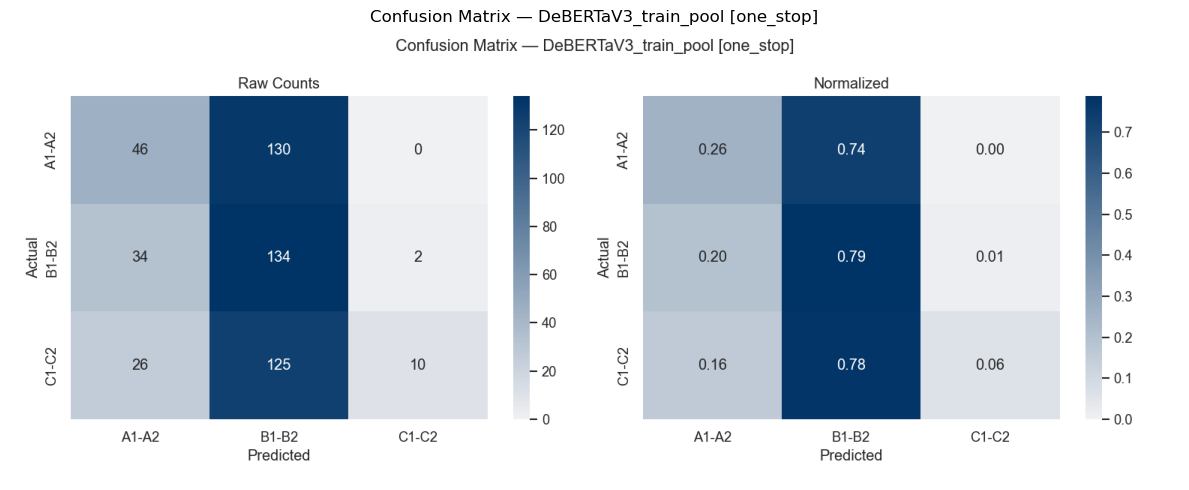

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool_one_stop.png
DeBERTaV3_train_pool [one_stop]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/debertav3_train_pool/one_stop/metrics_latest.json)
DeBERTaV3_train_pool [one_stop] | EVAL metrics: {'accuracy': 0.3747534516765286, 'f1_macro': 0.3070918734543164, 'f1_weighted': 0.31071763282537734}
Final evaluation F1 (macro) [DeBERTaV3_train_pool [one_stop]]: 0.3071 (cached)
DeBERTaV3_train_pool [commonlit]: loaded cached predictions -> eval_preds_latest.npy


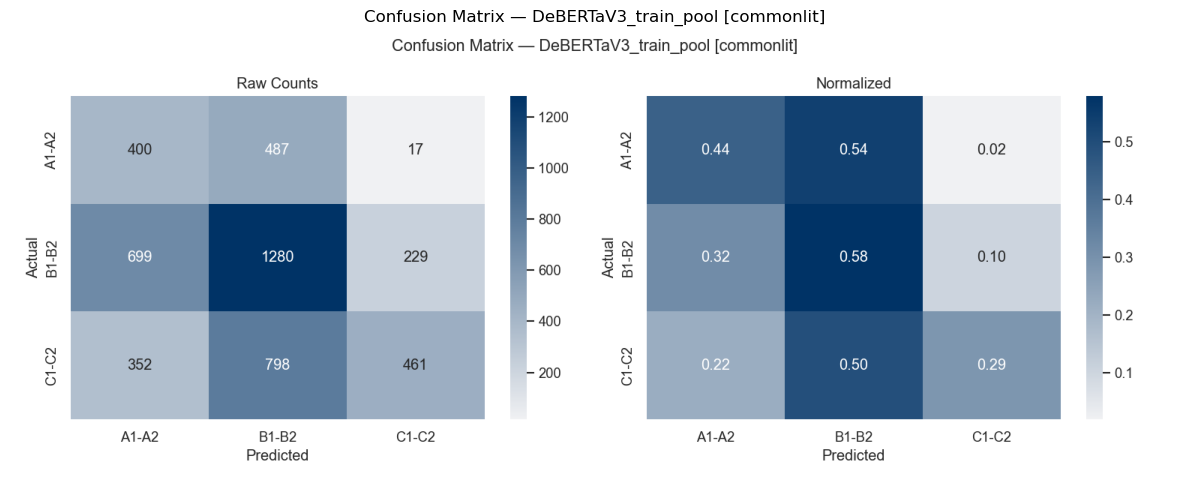

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool_commonlit.png
DeBERTaV3_train_pool [commonlit]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/debertav3_train_pool/commonlit/metrics_latest.json)
DeBERTaV3_train_pool [commonlit] | EVAL metrics: {'accuracy': 0.4533135718822782, 'f1_macro': 0.42460325022535156, 'f1_weighted': 0.4514373890160922}
Final evaluation F1 (macro) [DeBERTaV3_train_pool [commonlit]]: 0.4246 (cached)
DeBERTaV3_train_pool [cerf]: loaded cached predictions -> eval_preds_latest.npy


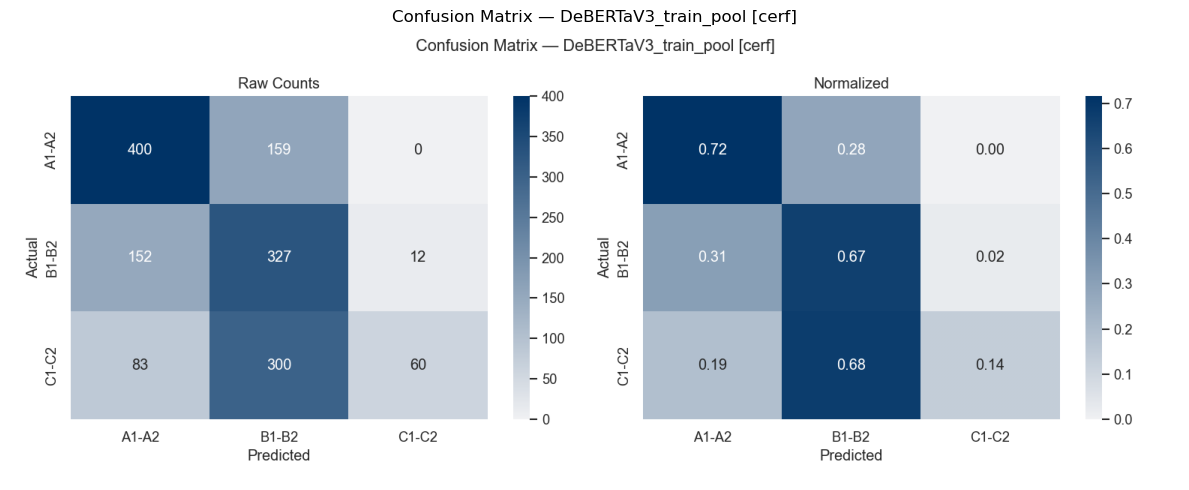

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool_cerf.png
DeBERTaV3_train_pool [cerf]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/debertav3_train_pool/cerf/metrics_latest.json)
DeBERTaV3_train_pool [cerf] | EVAL metrics: {'accuracy': 0.5271265907568654, 'f1_macro': 0.47172142739311135, 'f1_weighted': 0.4884275522833967}
Final evaluation F1 (macro) [DeBERTaV3_train_pool [cerf]]: 0.4717 (cached)
DeBERTaV3_train_pool [cambridge]: loaded cached predictions -> eval_preds_latest.npy


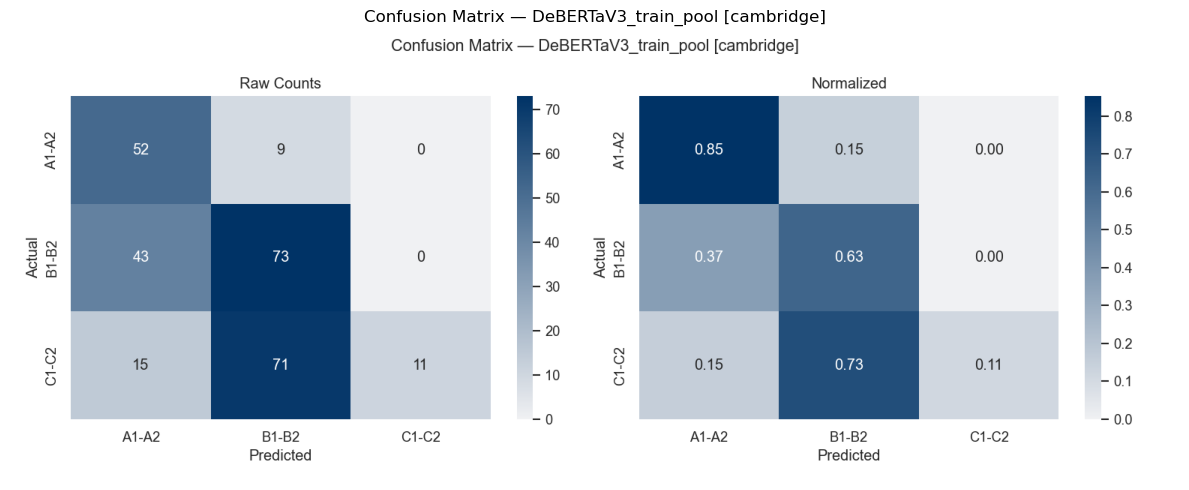

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool_cambridge.png
DeBERTaV3_train_pool [cambridge]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/debertav3_train_pool/cambridge/metrics_latest.json)
DeBERTaV3_train_pool [cambridge] | EVAL metrics: {'accuracy': 0.49635036496350365, 'f1_macro': 0.45154725585821914, 'f1_weighted': 0.4372911761701791}
Final evaluation F1 (macro) [DeBERTaV3_train_pool [cambridge]]: 0.4515 (cached)
DeBERTaV3_train_pool [asap_aes]: loaded cached predictions -> eval_preds_latest.npy


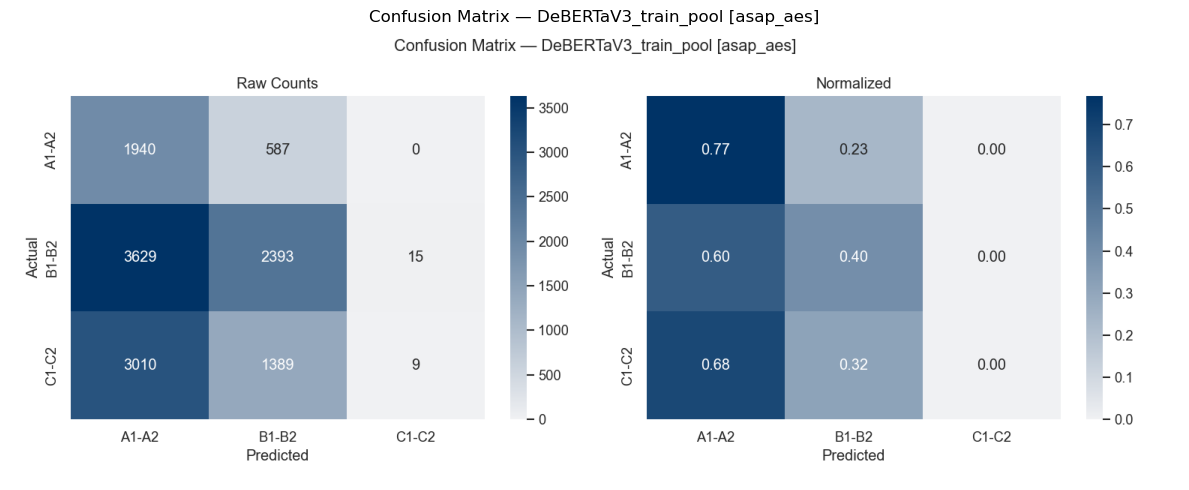

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_debertav3_train_pool_asap_aes.png
DeBERTaV3_train_pool [asap_aes]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/debertav3_train_pool/asap_aes/metrics_latest.json)
DeBERTaV3_train_pool [asap_aes] | EVAL metrics: {'accuracy': 0.3347209374036386, 'f1_macro': 0.27111634765941933, 'f1_weighted': 0.283481045323367}
Final evaluation F1 (macro) [DeBERTaV3_train_pool [asap_aes]]: 0.2711 (cached)
DistilBERT_train_pool [one_stop]: loaded cached predictions -> eval_preds_latest.npy


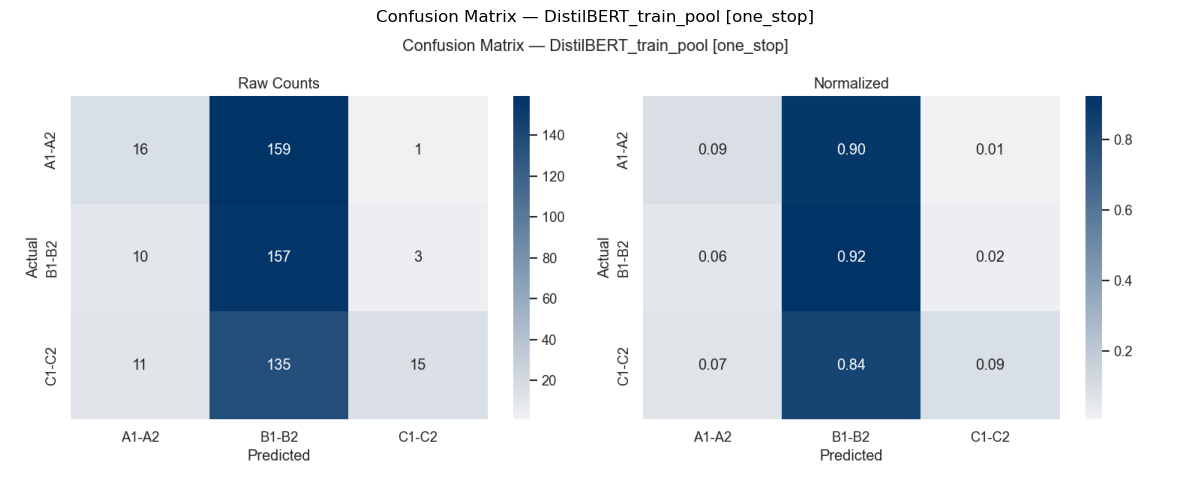

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool_one_stop.png
DistilBERT_train_pool [one_stop]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/distilbert_train_pool/one_stop/metrics_latest.json)
DistilBERT_train_pool [one_stop] | EVAL metrics: {'accuracy': 0.3708086785009862, 'f1_macro': 0.27417915976805546, 'f1_weighted': 0.27462086771678995}
Final evaluation F1 (macro) [DistilBERT_train_pool [one_stop]]: 0.2742 (cached)
DistilBERT_train_pool [commonlit]: loaded cached predictions -> eval_preds_latest.npy


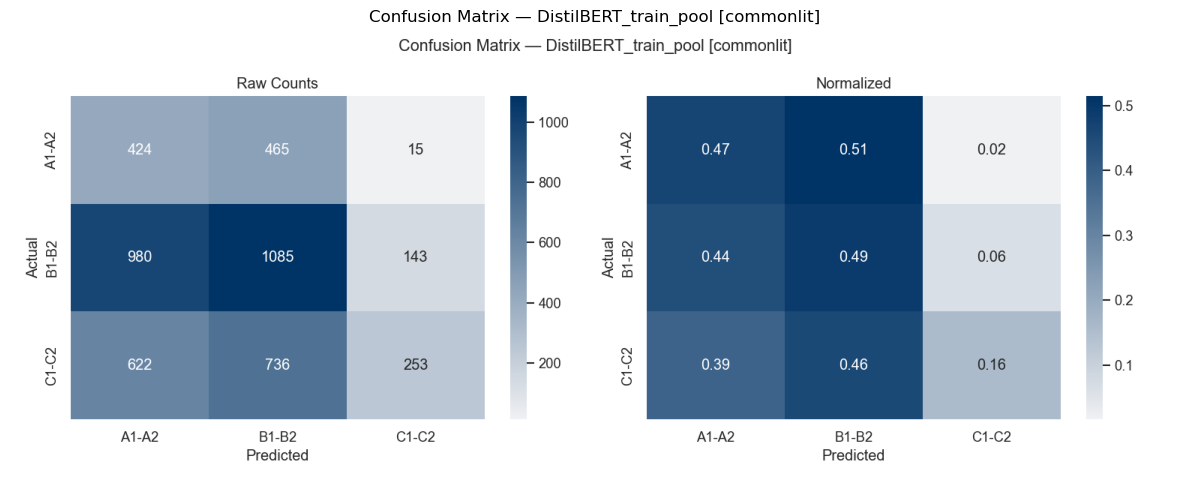

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool_commonlit.png
DistilBERT_train_pool [commonlit]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/distilbert_train_pool/commonlit/metrics_latest.json)
DistilBERT_train_pool [commonlit] | EVAL metrics: {'accuracy': 0.3730679652763074, 'f1_macro': 0.34084437291880687, 'f1_weighted': 0.3664941958780719}
Final evaluation F1 (macro) [DistilBERT_train_pool [commonlit]]: 0.3408 (cached)
DistilBERT_train_pool [cerf]: loaded cached predictions -> eval_preds_latest.npy


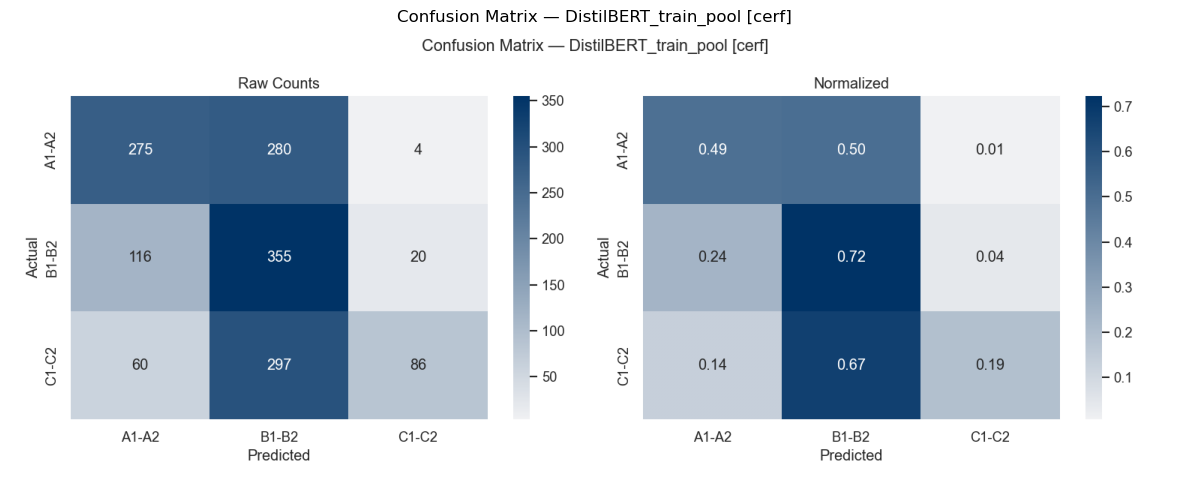

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool_cerf.png
DistilBERT_train_pool [cerf]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/distilbert_train_pool/cerf/metrics_latest.json)
DistilBERT_train_pool [cerf] | EVAL metrics: {'accuracy': 0.4795713328868051, 'f1_macro': 0.4515103619410013, 'f1_weighted': 0.4602645616354244}
Final evaluation F1 (macro) [DistilBERT_train_pool [cerf]]: 0.4515 (cached)
DistilBERT_train_pool [cambridge]: loaded cached predictions -> eval_preds_latest.npy


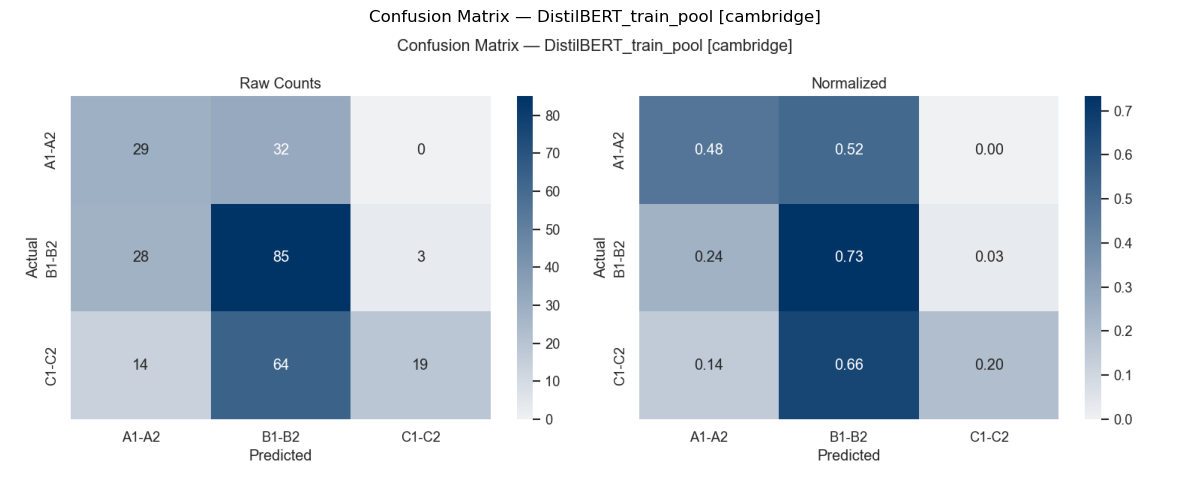

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool_cambridge.png
DistilBERT_train_pool [cambridge]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/distilbert_train_pool/cambridge/metrics_latest.json)
DistilBERT_train_pool [cambridge] | EVAL metrics: {'accuracy': 0.4854014598540146, 'f1_macro': 0.4437040809589829, 'f1_weighted': 0.4531938927602302}
Final evaluation F1 (macro) [DistilBERT_train_pool [cambridge]]: 0.4437 (cached)
DistilBERT_train_pool [asap_aes]: loaded cached predictions -> eval_preds_latest.npy


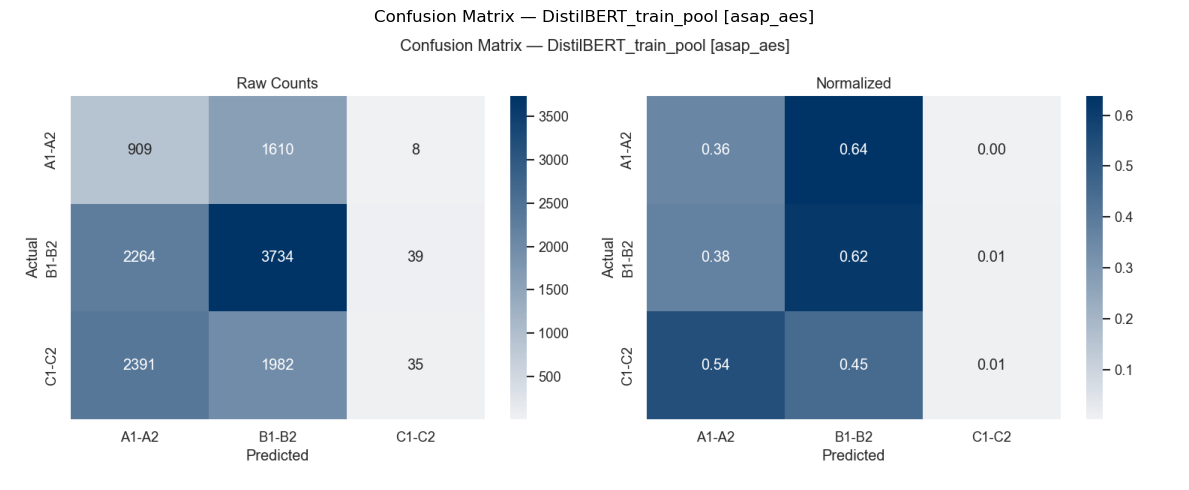

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool_asap_aes.png
DistilBERT_train_pool [asap_aes]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/distilbert_train_pool/asap_aes/metrics_latest.json)
DistilBERT_train_pool [asap_aes] | EVAL metrics: {'accuracy': 0.360622880049337, 'f1_macro': 0.26638028306507877, 'f1_weighted': 0.3091536049227754}
Final evaluation F1 (macro) [DistilBERT_train_pool [asap_aes]]: 0.2664 (cached)
RoBERTa_train_pool [one_stop]: loaded cached predictions -> eval_preds_latest.npy


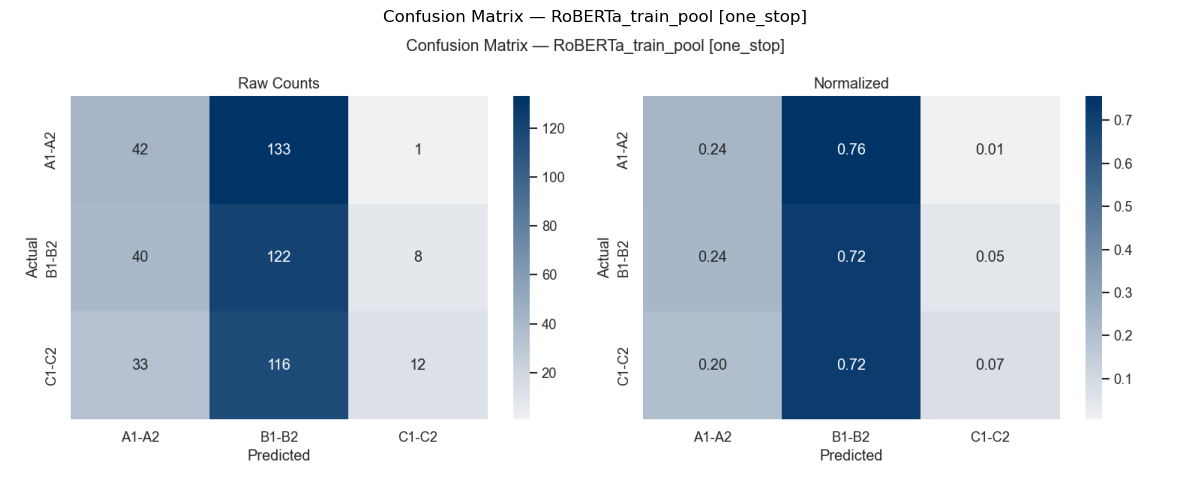

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool_one_stop.png
RoBERTa_train_pool [one_stop]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/roberta_train_pool/one_stop/metrics_latest.json)
RoBERTa_train_pool [one_stop] | EVAL metrics: {'accuracy': 0.34714003944773175, 'f1_macro': 0.2905148538473614, 'f1_weighted': 0.29330911447382196}
Final evaluation F1 (macro) [RoBERTa_train_pool [one_stop]]: 0.2905 (cached)
RoBERTa_train_pool [commonlit]: loaded cached predictions -> eval_preds_latest.npy


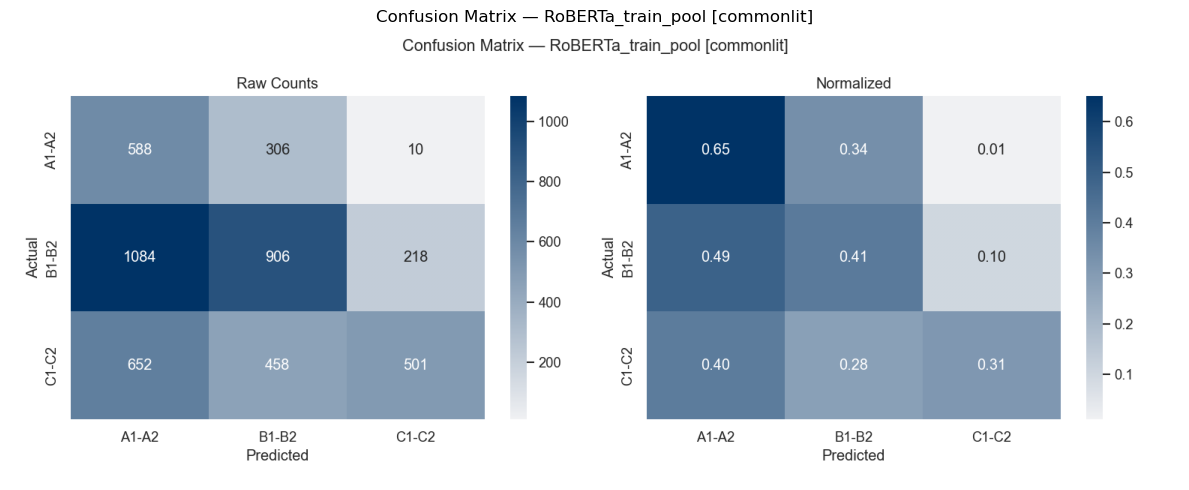

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool_commonlit.png
RoBERTa_train_pool [commonlit]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/roberta_train_pool/commonlit/metrics_latest.json)
RoBERTa_train_pool [commonlit] | EVAL metrics: {'accuracy': 0.4224010163031971, 'f1_macro': 0.4199228520850251, 'f1_weighted': 0.43422979327688394}
Final evaluation F1 (macro) [RoBERTa_train_pool [commonlit]]: 0.4199 (cached)
RoBERTa_train_pool [cerf]: loaded cached predictions -> eval_preds_latest.npy


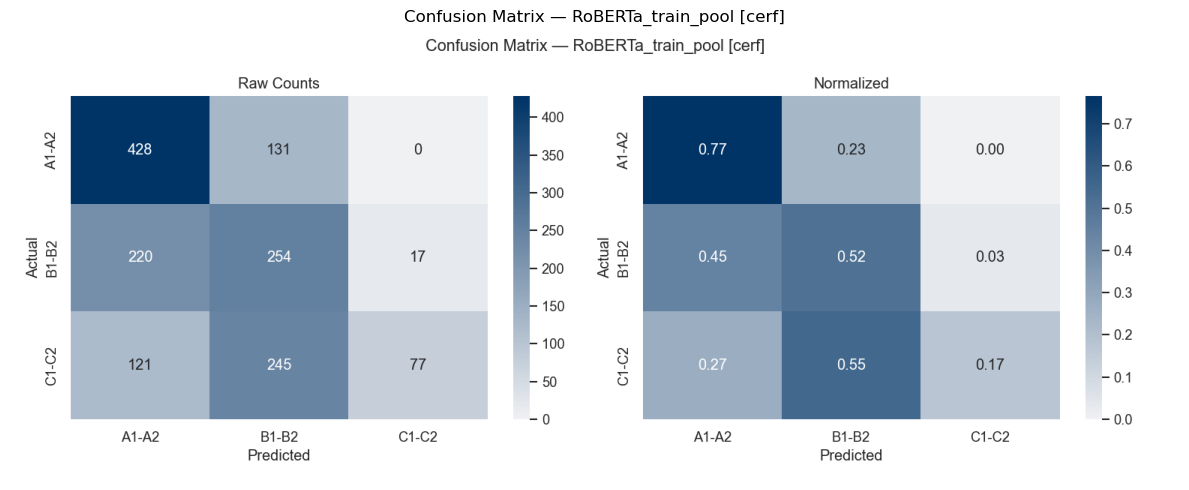

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool_cerf.png
RoBERTa_train_pool [cerf]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/roberta_train_pool/cerf/metrics_latest.json)
RoBERTa_train_pool [cerf] | EVAL metrics: {'accuracy': 0.5083724045545881, 'f1_macro': 0.4615078423688992, 'f1_weighted': 0.4754635056812469}
Final evaluation F1 (macro) [RoBERTa_train_pool [cerf]]: 0.4615 (cached)
RoBERTa_train_pool [cambridge]: loaded cached predictions -> eval_preds_latest.npy


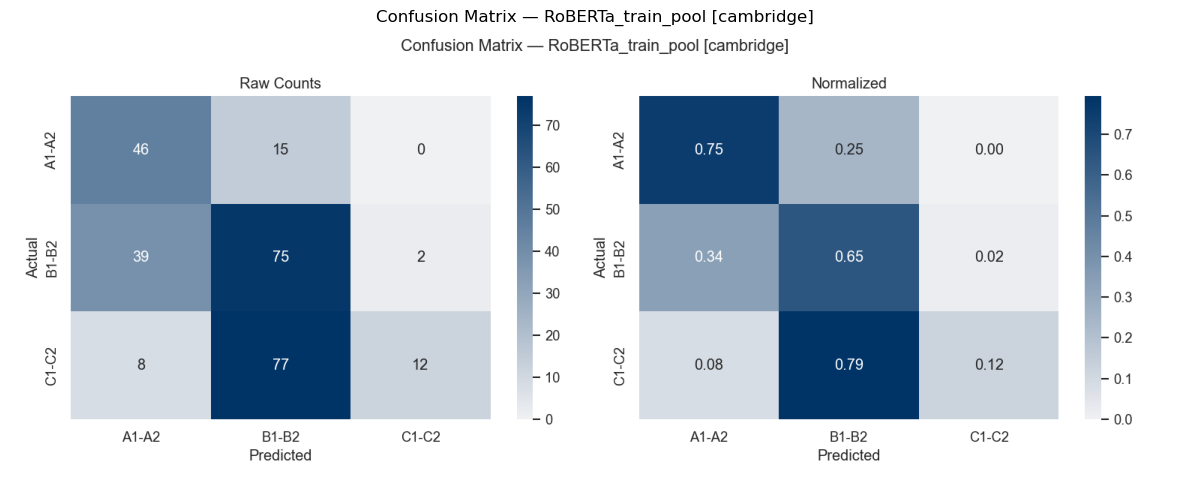

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool_cambridge.png
RoBERTa_train_pool [cambridge]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/roberta_train_pool/cambridge/metrics_latest.json)
RoBERTa_train_pool [cambridge] | EVAL metrics: {'accuracy': 0.4854014598540146, 'f1_macro': 0.4478847164359532, 'f1_weighted': 0.4339366071330684}
Final evaluation F1 (macro) [RoBERTa_train_pool [cambridge]]: 0.4479 (cached)
RoBERTa_train_pool [asap_aes]: loaded cached predictions -> eval_preds_latest.npy


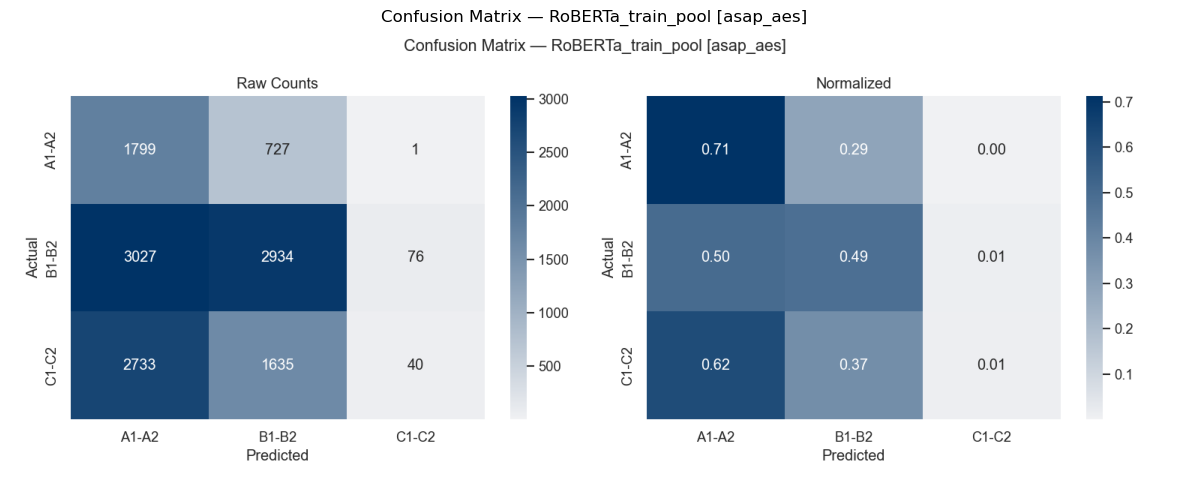

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool_asap_aes.png
RoBERTa_train_pool [asap_aes]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/transformer/roberta_train_pool/asap_aes/metrics_latest.json)
RoBERTa_train_pool [asap_aes] | EVAL metrics: {'accuracy': 0.3679463459759482, 'f1_macro': 0.2973971988738055, 'f1_weighted': 0.3164686235038553}
Final evaluation F1 (macro) [RoBERTa_train_pool [asap_aes]]: 0.2974 (cached)
Cross-dataset transformer artefacts saved under: outputs/cross_dataset_eval/transformer


In [34]:
# -- 7.2 Cross-dataset eval for all transformers ----------------------------
shared_model_dir = CFG["model_dir"] / "shared"
if "le" not in globals():
    le = load_saved_label_encoder(shared_model_dir, class2id)

TRANSFORMER_CROSS_DATASET_EVAL = {}
transformer_registry_df = load_transformer_registry(CFG)
globals()["transformer_summary_df"] = transformer_registry_df.copy()
display(transformer_registry_df.round(4))

for row in transformer_registry_df.itertuples(index=False):
    transformer_name = str(row.experiment)
    best_model_dir = Path(row.best_model)

    TRANSFORMER_CROSS_DATASET_EVAL[transformer_name] = {}

    for dataset_name, bundle in external_eval_bundles.items():
        cross_eval_dir = (
            CFG["output_dir"] / "cross_dataset_eval" / "transformer" /
            slugify(transformer_name) / dataset_name
        )
        cross_eval_dir.mkdir(parents=True, exist_ok=True)

        data_path = DATASET_SOURCE_PATHS.get(dataset_name)
        display_name = f"{transformer_name} [{dataset_name}]"

        if CFG.get("run_transformer_eval", True):
            if not best_model_dir.exists():
                print(f"Skipping {transformer_name}: best model directory not found -> {best_model_dir}")
                continue

            payload = run_cross_dataset_transformer_eval(
                display_name=display_name,
                data_bundle=bundle,
                output_dir=cross_eval_dir,
                best_model_dir=best_model_dir,
                data_paths=data_path,
            )
        else:
            payload = render_cached_cross_dataset_eval(
                display_name=display_name,
                output_dir=cross_eval_dir,
                bundle_name=dataset_name,
            )

        payload["canonical_model"] = transformer_name
        payload["dataset_name"] = dataset_name
        TRANSFORMER_CROSS_DATASET_EVAL[transformer_name][dataset_name] = payload

print(
    f"Cross-dataset transformer artefacts saved under: "
    f"{CFG['output_dir'] / 'cross_dataset_eval' / 'transformer'}"
)

<a id="section-7-3-aggregated-metrics"></a>
## 7.3 Aggregated Metrics

In [35]:
# -- 7.3 Aggregate cross-dataset metrics across model families --------------
cross_dataset_rows = []

for dataset_name, payloads in sorted(CLASSICAL_EXTERNAL_EVAL.items()):
    for model_name, payload in sorted(payloads.items()):
        eval_metrics = payload.get("metrics", {}).get("eval", {})
        cross_dataset_rows.append({
            "family": "classical",
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": float(eval_metrics.get("accuracy", np.nan)),
            "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
        })

for dataset_name, payloads in sorted(DEEP_EXTERNAL_EVAL.items()):
    for model_name, payload in sorted(payloads.items()):
        eval_metrics = payload.get("metrics", {}).get("eval", {})
        cross_dataset_rows.append({
            "family": "deep",
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": float(eval_metrics.get("accuracy", np.nan)),
            "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
        })

for transformer_name, dataset_payloads in sorted(TRANSFORMER_CROSS_DATASET_EVAL.items()):
    for dataset_name, payload in sorted(dataset_payloads.items()):
        eval_metrics = payload.get("metrics", {}).get("eval", {})
        cross_dataset_rows.append({
            "family": "transformer",
            "dataset": dataset_name,
            "model": transformer_name,
            "accuracy": float(eval_metrics.get("accuracy", np.nan)),
            "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
        })


if cross_dataset_rows:
    cross_dataset_summary_df = (
        pd.DataFrame(cross_dataset_rows)
        .sort_values(["family", "dataset", "f1_macro"], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    baseline_external_eval_df = cross_dataset_summary_df.query("family == 'classical'").reset_index(drop=True)
    deep_external_eval_df = cross_dataset_summary_df.query("family == 'deep'").reset_index(drop=True)
    transformer_external_summary_df = cross_dataset_summary_df.query("family == 'transformer'").reset_index(drop=True)

    cross_dataset_family_summary_df = (
        cross_dataset_summary_df
        .groupby("family", as_index=False)[["accuracy", "f1_macro", "f1_weighted"]]
        .mean()
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )

    display(cross_dataset_summary_df.round(4))
    display(cross_dataset_family_summary_df.round(4))

    cross_dataset_root = CFG["output_dir"] / "cross_dataset_eval"
    cross_dataset_root.mkdir(parents=True, exist_ok=True)
    cross_dataset_summary_df.to_csv(cross_dataset_root / "summary_latest.csv", index=False)
    cross_dataset_family_summary_df.to_csv(cross_dataset_root / "family_summary_latest.csv", index=False)
    print(f"Cross-dataset summary saved to: {cross_dataset_root / 'summary_latest.csv'}")
else:
    cross_dataset_summary_df = pd.DataFrame(
        columns=["family", "dataset", "model", "accuracy", "f1_macro", "f1_weighted"]
    )
    baseline_external_eval_df = cross_dataset_summary_df.copy()
    deep_external_eval_df = cross_dataset_summary_df.copy()
    transformer_external_summary_df = cross_dataset_summary_df.copy()
    cross_dataset_family_summary_df = pd.DataFrame(
        columns=["family", "accuracy", "f1_macro", "f1_weighted"]
    )
    print("No cross-dataset evaluations were collected.")


,family,dataset,model,accuracy,f1_macro,f1_weighted
0,classical,asap_aes,TF-IDF + LogReg,0.5168,0.4867,0.5132
1,classical,asap_aes,TF-IDF + SVC,0.4990,0.4516,0.4830
2,classical,asap_aes,TF-IDF + XGBoost,0.3950,0.2348,0.2892
3,classical,asap_aes,Majority Class,0.4654,0.2117,0.2956
4,classical,cambridge,TF-IDF + SVC,0.5620,0.5142,0.5423
5,classical,cambridge,TF-IDF + LogReg,0.5146,0.4777,0.4884
6,classical,cambridge,TF-IDF + XGBoost,0.5401,0.4629,0.4972
7,classical,cambridge,Majority Class,0.4234,0.1983,0.2518
8,classical,cerf,TF-IDF + SVC,0.5244,0.5244,0.5192
9,classical,cerf,TF-IDF + LogReg,0.5171,0.5046,0.5008


,family,accuracy,f1_macro,f1_weighted
0,deep,0.4585,0.3971,0.4140
1,transformer,0.4258,0.3747,0.3859
2,classical,0.4458,0.3359,0.3630


Cross-dataset summary saved to: outputs/cross_dataset_eval/summary_latest.csv


<a id="section-7-4-visualization"></a>
## 7.4 Visualization

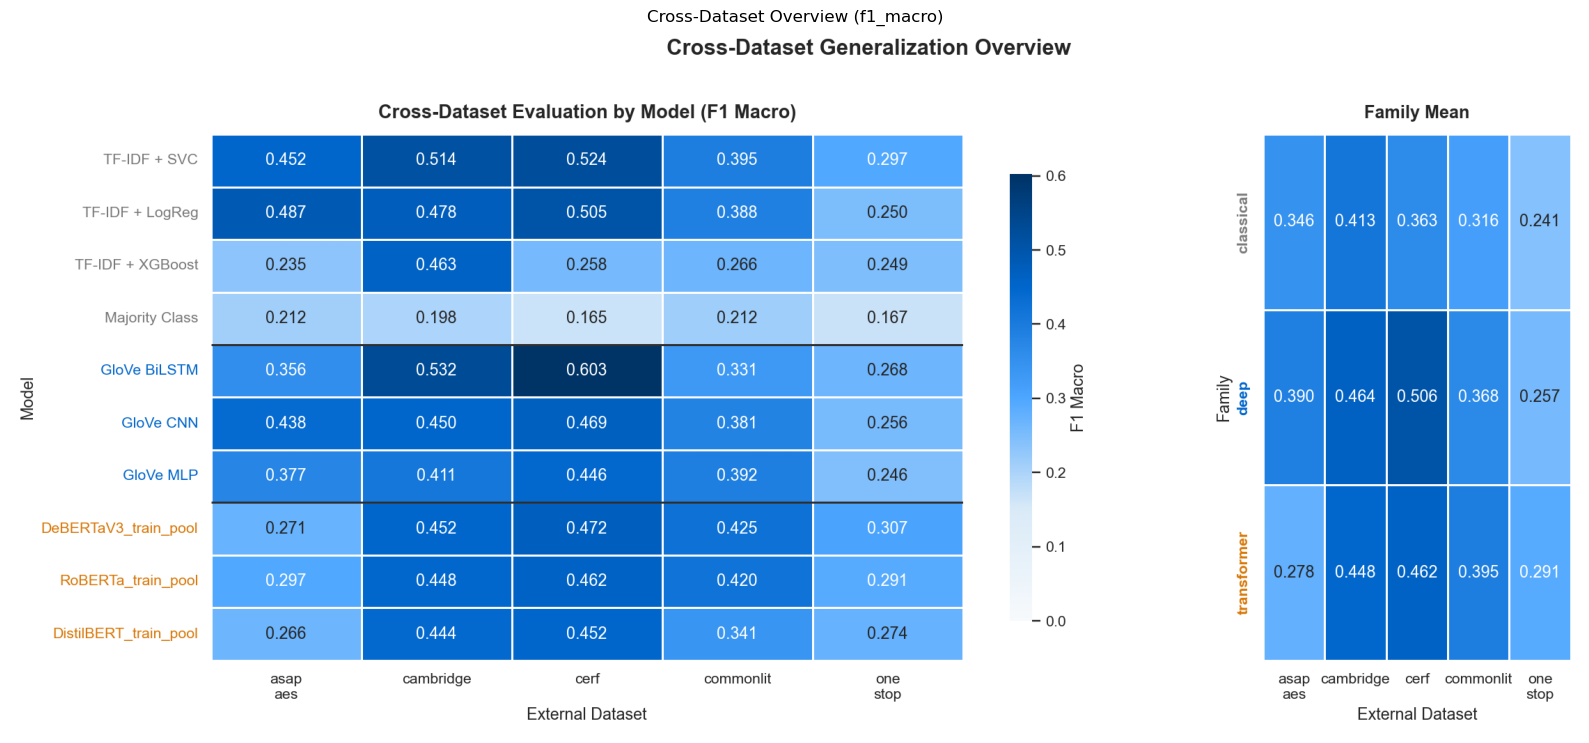

Displayed existing plot: outputs/cross_dataset_eval/plots/cross_dataset_overview_f1_macro.png


In [36]:
# -- 7.4 Cross-dataset visualization ----------------------------------------

cross_dataset_plot_df = (
    cross_dataset_summary_df.copy()
    if "cross_dataset_summary_df" in globals() and not cross_dataset_summary_df.empty
    else pd.read_csv(CFG["output_dir"] / "cross_dataset_eval" / "summary_latest.csv")
)

plot_cross_dataset_overview(
    cross_dataset_plot_df,
    metric="f1_macro",
    force_replot=False,
)


---
<a id="section-8-model-comparison-results-table"></a>
# SECTION 8 — Model Comparison & Results Table
We collect everything in one place for a final comparison.
We get the consolidated table, comparison plots, and a small error sample, and we can read the ranking at a glance before writing the full report.


In [37]:
# -- 8.1 Save artefacts -----------------------------------------------------
if not RESULTS:
    restored_results_count = restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )
    print(f"RESULTS restored from saved artifacts: {restored_results_count}")

save_artefacts()


Artefacts saved  ->  outputs/metrics  |  models/shared


In [38]:
# -- 8.2 Build and persist the consolidated results table -------------------
if not RESULTS:
    restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )

if RESULTS:
    df_results = (
        pd.DataFrame(RESULTS)
        .T
        .rename_axis("Model | Split")
        .reset_index()
    )
    df_results[["model_name", "metric_split"]] = df_results["Model | Split"].str.rsplit(" | ", n=1, expand=True)
    df_results = df_results.sort_values(["metric_split", "f1_macro"], ascending=[True, False]).reset_index(drop=True)
else:
    df_results = load_saved_results_df(CFG)

if df_results.empty:
    print("No results available. Run earlier sections or ensure saved result artifacts exist.")
else:
    display(df_results.round(4))

    metrics_dir = CFG["output_paths"]["metrics"]
    joblib.dump(df_results, metrics_dir / f"results_{CFG['task']}.pkl")
    print("Results saved.")

    internal_test_leaderboard_df = (
        df_results[
            (df_results["metric_split"] == "test") &
            (~df_results["model_name"].str.startswith("LC |"))
        ]
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )
    display(internal_test_leaderboard_df.head(15).round(4))
    internal_test_leaderboard_df.to_csv(metrics_dir / "internal_test_leaderboard.csv", index=False)
    joblib.dump(internal_test_leaderboard_df, metrics_dir / "internal_test_leaderboard.pkl")


,Model | Split,accuracy,f1_macro,f1_weighted,loss,model_name,metric_split
0,DeBERTaV3_train_pool | test,0.7791,0.7511,0.7761,0.5337,DeBERTaV3_train_pool,test
1,DistilBERT_train_pool | test,0.7746,0.7431,0.7721,NaN,DistilBERT_train_pool,test
2,RoBERTa_train_pool | test,0.7676,0.7298,0.7645,NaN,RoBERTa_train_pool,test
3,TF-IDF + SVC [train_pool] | test,0.7003,0.6687,0.6998,NaN,TF-IDF + SVC [train_pool],test
4,TF-IDF + LogReg [train_pool] | test,0.6836,0.6608,0.6864,NaN,TF-IDF + LogReg [train_pool],test
5,GloVe BiLSTM [train_pool] | test,0.6927,0.6552,0.6923,NaN,GloVe BiLSTM [train_pool],test
6,GloVe CNN [train_pool] | test,0.6795,0.6388,0.6767,NaN,GloVe CNN [train_pool],test
7,GloVe MLP [train_pool] | test,0.6527,0.5964,0.6427,NaN,GloVe MLP [train_pool],test
8,TF-IDF + XGBoost [train_pool] | test,0.6739,0.5342,0.6344,NaN,TF-IDF + XGBoost [train_pool],test
9,Majority Class [train_pool] | test,0.5448,0.2351,0.3843,NaN,Majority Class [train_pool],test


Results saved.


,Model | Split,accuracy,f1_macro,f1_weighted,loss,model_name,metric_split
0,DeBERTaV3_train_pool | test,0.7791,0.7511,0.7761,0.5337,DeBERTaV3_train_pool,test
1,DistilBERT_train_pool | test,0.7746,0.7431,0.7721,NaN,DistilBERT_train_pool,test
2,RoBERTa_train_pool | test,0.7676,0.7298,0.7645,NaN,RoBERTa_train_pool,test
3,TF-IDF + SVC [train_pool] | test,0.7003,0.6687,0.6998,NaN,TF-IDF + SVC [train_pool],test
4,TF-IDF + LogReg [train_pool] | test,0.6836,0.6608,0.6864,NaN,TF-IDF + LogReg [train_pool],test
5,GloVe BiLSTM [train_pool] | test,0.6927,0.6552,0.6923,NaN,GloVe BiLSTM [train_pool],test
6,GloVe CNN [train_pool] | test,0.6795,0.6388,0.6767,NaN,GloVe CNN [train_pool],test
7,GloVe MLP [train_pool] | test,0.6527,0.5964,0.6427,NaN,GloVe MLP [train_pool],test
8,TF-IDF + XGBoost [train_pool] | test,0.6739,0.5342,0.6344,NaN,TF-IDF + XGBoost [train_pool],test
9,Majority Class [train_pool] | test,0.5448,0.2351,0.3843,NaN,Majority Class [train_pool],test


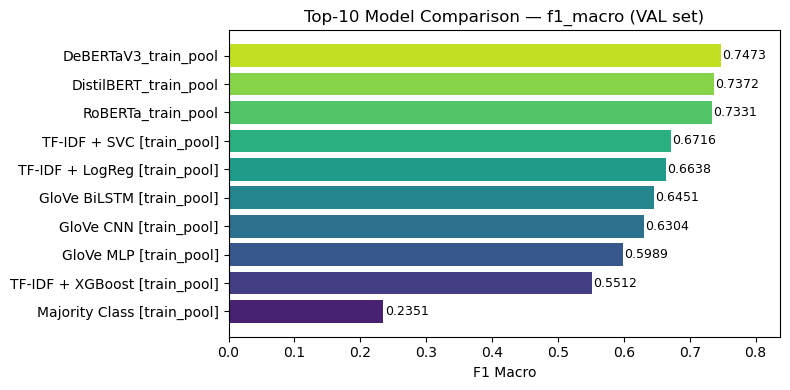

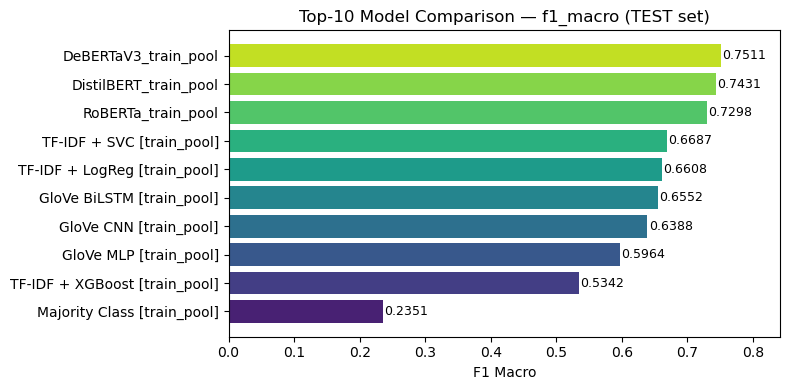

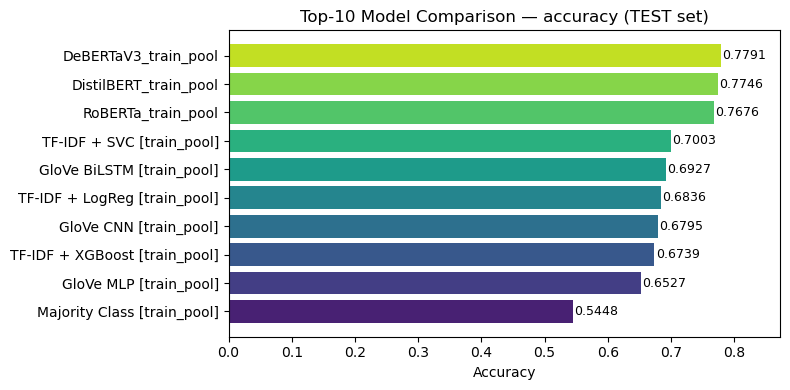

In [39]:
top10_val_f1_df = get_top_models_df(RESULTS, split="val", metric="f1_macro", top_n=10)
top10_test_f1_df = get_top_models_df(RESULTS, split="test", metric="f1_macro", top_n=10)
top10_test_acc_df = get_top_models_df(RESULTS, split="test", metric="accuracy", top_n=10)

metrics_dir = CFG["output_paths"]["metrics"]
if not top10_val_f1_df.empty:
    top10_val_f1_df.to_csv(metrics_dir / "top10_val_f1_macro.csv", index=False)
if not top10_test_f1_df.empty:
    top10_test_f1_df.to_csv(metrics_dir / "top10_test_f1_macro.csv", index=False)
if not top10_test_acc_df.empty:
    top10_test_acc_df.to_csv(metrics_dir / "top10_test_accuracy.csv", index=False)

plot_top_model_comparison(RESULTS, metric="f1_macro", split="val", top_n=10)
plot_top_model_comparison(RESULTS, metric="f1_macro", split="test", top_n=10)
plot_top_model_comparison(RESULTS, metric="accuracy", split="test", top_n=10);

In [40]:
# -- 8.4 Error analysis for the final transformer ---------------------------
shared_model_dir = CFG["model_dir"] / "shared"
if "le" not in globals():
    le = load_saved_label_encoder(shared_model_dir, class2id)

print(f"=== Error Analysis — {globals().get('FINAL_TRANSFORMER_NAME', 'Transformer')} ===")
error_path = CFG["output_paths"]["metrics"] / "final_transformer_error_analysis.csv"

if CFG.get("run_transformer_eval", True):
    restore_final_transformer_test_artifacts(CFG)

    if len(globals().get("trf_test_preds", [])) == len(globals().get("trf_y_test", [])) and len(globals().get("trf_y_test", [])) > 0:
        error_df = error_analysis(
            trf_df_test,
            trf_y_test,
            trf_test_preds,
            le,
            n=10,
        )
        error_df.to_csv(error_path, index=False)
        print(f"Saved final transformer error analysis -> {error_path}")
    elif error_path.exists():
        error_df = pd.read_csv(error_path)
        print(f"Loaded saved final transformer error analysis -> {error_path}")
    else:
        raise FileNotFoundError(
            "Final transformer predictions are not available and no saved error-analysis CSV was found. "
            "Run the transformer evaluation once to persist test predictions."
        )
else:
    if error_path.exists():
        error_df = pd.read_csv(error_path)
        print(f"Loaded saved final transformer error analysis -> {error_path}")
    else:
        raise FileNotFoundError(
            f"Cached error-analysis CSV not found: {error_path}. "
            "Set CFG['run_transformer_eval']=True and run transformer evaluation once."
        )

display(error_df)

=== Error Analysis — DeBERTaV3_train_pool ===
Loaded saved final transformer error analysis -> outputs/metrics/final_transformer_error_analysis.csv


,text,true_label,pred_label
0,Even in the thickest undergrowth you were whip...,A1-A2,B1-B2
1,It is good against the Gout; it comforts the h...,A1-A2,C1-C2
2,The author said that studying Venus is a worth...,B1-B2,A1-A2
3,"From his garden, Mr. Collins would have led th...",B1-B2,C1-C2
4,Driverless cars The point that the article is ...,B1-B2,A1-A2
5,"Dear Senator, What do you think about descardi...",A1-A2,B1-B2
6,"Frank put the sack carefully to one side, then...",A1-A2,C1-C2
7,Luke had many reasons to join the program. He ...,A1-A2,B1-B2
8,when no one buys cars because no one needs the...,A1-A2,B1-B2
9,Dear senator i think that the electoral collag...,B1-B2,A1-A2


---
<a id="section-9-saving-logging-final-report"></a>
# SECTION 9 — Saving, Logging & Final Report
We save the main artefacts and sanity-check the best model on short real sentences.
We get reusable outputs and quick manual predictions, and we can confirm that obvious cases look sensible while borderline ones stay trickier.


<a id="section-9-1-save-artefacts"></a>
## 9.1 Save Artefacts

In [41]:
# -- 9.1 Save artefacts ----------------------------------------------------
if not RESULTS:
    restored_results_count = restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )
    print(f"RESULTS restored from saved artifacts: {restored_results_count}")

save_artefacts()

metrics_dir = CFG["output_paths"]["metrics"]
if "df_results" in globals() and isinstance(df_results, pd.DataFrame) and not df_results.empty:
    joblib.dump(df_results, metrics_dir / f"results_{CFG['task']}.pkl")
if "internal_test_leaderboard_df" in globals() and isinstance(internal_test_leaderboard_df, pd.DataFrame) and not internal_test_leaderboard_df.empty:
    internal_test_leaderboard_df.to_csv(metrics_dir / "internal_test_leaderboard.csv", index=False)
    joblib.dump(internal_test_leaderboard_df, metrics_dir / "internal_test_leaderboard.pkl")
if "error_df" in globals() and isinstance(error_df, pd.DataFrame) and not error_df.empty:
    error_df.to_csv(metrics_dir / "final_transformer_error_analysis.csv", index=False)

print(f"Stable artefacts refreshed under: {metrics_dir}")


Artefacts saved  ->  outputs/metrics  |  models/shared
Stable artefacts refreshed under: outputs/metrics


<a id="section-9-2-manual-inference-sanity-check"></a>
## 9.2 Manual Inference Sanity Check

In [42]:
# -- 9.2.1 Load DeBERTa and GloVe BiLSTM for manual checks -----------------
if CFG.get("run_transformer_eval", True):
    shared_model_dir = CFG["model_dir"] / "shared"
    if "le" not in globals():
        le = load_saved_label_encoder(shared_model_dir, class2id)
    if "vocab" not in globals():
        vocab = joblib.load(shared_model_dir / "vocab.pkl")

    device = torch.device(CFG["device"])
    MANUAL_MODELS = {}

    transformer_summary_manual_df = load_saved_transformer_summary(CFG)
    debarta_row = transformer_summary_manual_df.loc[
        transformer_summary_manual_df["experiment"] == "DeBERTaV3_train_pool"
    ]
    if not debarta_row.empty:
        DEBERTA_MODEL_PATH = Path(debarta_row.iloc[0]["best_model"])
        deberta_tokenizer = AutoTokenizer.from_pretrained(str(DEBERTA_MODEL_PATH), use_fast=True)
        deberta_model = AutoModelForSequenceClassification.from_pretrained(str(DEBERTA_MODEL_PATH)).to(device)
        deberta_model.eval()
        tokenizer = deberta_tokenizer
        model = deberta_model
        MODEL_PATH = str(DEBERTA_MODEL_PATH)
        MANUAL_MODELS["DeBERTaV3"] = {
            "family": "transformer",
            "tokenizer": deberta_tokenizer,
            "model": deberta_model,
            "path": DEBERTA_MODEL_PATH,
        }
        print(f"Loaded DeBERTaV3 for manual inference -> {DEBERTA_MODEL_PATH}")
    else:
        print("DeBERTaV3 best model was not found in transformer summary metrics.")

    try:
        glove_bilstm_bundle = load_saved_deep_model_for_inference(
            "GloVe BiLSTM",
            split_key=train_pool_key,
            cfg=CFG,
        )
        MANUAL_MODELS["GloVe BiLSTM"] = {
            "family": "deep",
            **glove_bilstm_bundle,
        }
        print(f"Loaded GloVe BiLSTM for manual inference -> {glove_bilstm_bundle['checkpoint']}")
    except Exception as e:
        print(f"Could not load GloVe BiLSTM for manual inference: {e}")
else:
    print("Skipping manual model loading because CFG['run_transformer_eval'] = False.")
    MANUAL_MODELS = {}

Skipping manual model loading because CFG['run_transformer_eval'] = False.


In [43]:
# -- 9.2.2 Example texts for manual complexity checks ----------------------
manual_examples_path = CFG["output_paths"]["metrics"] / "manual_example_predictions.csv"

if CFG.get("run_transformer_eval", True):
    example_texts = [
        "The boy has a small dog. The dog is brown and friendly.",
        "My sister goes to school by bus and comes home in the afternoon.",
        "The museum opened a new room where visitors can learn about life in ancient cities.",
        "Although the weather forecast predicted heavy rain, the match continued because the pitch remained playable.",
        "Researchers compared the two groups carefully in order to determine whether the intervention had any measurable effect.",
        "Notwithstanding the apparent simplicity of the proposal, its implementation would require a sequence of interdependent regulatory revisions.",
        "The committee acknowledged that, in the absence of reliable longitudinal evidence, any definitive conclusion would remain provisional.",
        "By foregrounding the tension between economic efficiency and social equity, the report complicates any straightforward interpretation of the policy debate.",
    ]

    manual_rows = []
    for i, text in enumerate(example_texts, start=1):
        row = {"example_id": i, "text": text}

        if "DeBERTaV3" in MANUAL_MODELS:
            pred_label, conf = predict_with_transformer_components(
                text,
                MANUAL_MODELS["DeBERTaV3"]["tokenizer"],
                MANUAL_MODELS["DeBERTaV3"]["model"],
                device,
                cfg=CFG,
                label_encoder=le,
            )
            row["DeBERTaV3_label"] = pred_label
            row["DeBERTaV3_conf"] = conf

        if "GloVe BiLSTM" in MANUAL_MODELS:
            pred_label, conf = predict_with_deep_components(
                text,
                MANUAL_MODELS["GloVe BiLSTM"]["model"],
                MANUAL_MODELS["GloVe BiLSTM"]["vocab"],
                device,
                cfg=CFG,
                label_encoder=le,
            )
            row["GloVe_BiLSTM_label"] = pred_label
            row["GloVe_BiLSTM_conf"] = conf

        manual_rows.append(row)

    manual_example_predictions_df = pd.DataFrame(manual_rows)
    display(manual_example_predictions_df)
    manual_example_predictions_df.to_csv(manual_examples_path, index=False)
    print(f"Saved manual example predictions -> {manual_examples_path}")
else:
    if manual_examples_path.exists():
        manual_example_predictions_df = pd.read_csv(manual_examples_path)
        display(manual_example_predictions_df)
        print(f"Loaded saved manual example predictions -> {manual_examples_path}")
    else:
        print(
            f"Skipping manual example predictions because CFG['run_transformer_eval'] = False "
            f"and cached file was not found: {manual_examples_path}"
        )
        manual_example_predictions_df = pd.DataFrame()

,example_id,text,DeBERTaV3_label,DeBERTaV3_conf,GloVe_BiLSTM_label,GloVe_BiLSTM_conf
0,1,The boy has a small dog. The dog is brown and ...,B1-B2,0.564528,B1-B2,0.954584
1,2,My sister goes to school by bus and comes home...,B1-B2,0.506016,A1-A2,0.683708
2,3,The museum opened a new room where visitors ca...,B1-B2,0.529735,B1-B2,0.521766
3,4,Although the weather forecast predicted heavy ...,B1-B2,0.481085,B1-B2,0.622028
4,5,Researchers compared the two groups carefully ...,B1-B2,0.454809,B1-B2,0.396315
5,6,Notwithstanding the apparent simplicity of the...,B1-B2,0.468166,C1-C2,0.967622
6,7,"The committee acknowledged that, in the absenc...",C1-C2,0.466888,A1-A2,0.459001
7,8,By foregrounding the tension between economic ...,B1-B2,0.447074,B1-B2,0.382493


Loaded saved manual example predictions -> outputs/metrics/manual_example_predictions.csv


<a id="section-9-3-final-report"></a>
## 9.3 Final Report
We built the complexity pipeline around one shared in-domain pool: UK Key Stage plus ASAP 2.0 are merged, stratified into train, validation, and internal test subsets, and reused consistently across model families.
All remaining corpora are kept out of training and prepared as external evaluation sets, so later sections can measure both internal performance and cross-dataset generalization with the same label mapping and preprocessing contract.
This keeps the notebook aligned with the age project’s workflow while adapting the split policy, labels, sequence length, and evaluation boundaries to the readability-complexity task.


In [44]:
# -- 9.3 Final report summary ----------------------------------------------
metrics_dir = CFG["output_paths"]["metrics"]
cross_dataset_root = CFG["output_dir"] / "cross_dataset_eval"
cross_dataset_root.mkdir(parents=True, exist_ok=True)

if "baseline_eval_df" not in globals() or baseline_eval_df is None or getattr(baseline_eval_df, "empty", True):
    baseline_eval_pkl = metrics_dir / "baseline_eval_metrics.pkl"
    baseline_eval_csv = metrics_dir / "baseline_eval_metrics.csv"
    if baseline_eval_pkl.exists():
        baseline_eval_df = joblib.load(baseline_eval_pkl)
    elif baseline_eval_csv.exists():
        baseline_eval_df = pd.read_csv(baseline_eval_csv)
    else:
        baseline_eval_df = pd.DataFrame()

if "deep_test_eval_df" not in globals() or deep_test_eval_df is None or getattr(deep_test_eval_df, "empty", True):
    deep_test_eval_pkl = metrics_dir / "deep_eval_metrics_test.pkl"
    deep_test_eval_csv = metrics_dir / "deep_eval_metrics_test.csv"
    if deep_test_eval_pkl.exists():
        deep_test_eval_df = joblib.load(deep_test_eval_pkl)
    elif deep_test_eval_csv.exists():
        deep_test_eval_df = pd.read_csv(deep_test_eval_csv)
    else:
        deep_test_eval_df = pd.DataFrame()

if "transformer_summary_df" not in globals() or transformer_summary_df is None or getattr(transformer_summary_df, "empty", True):
    transformer_summary_df = load_saved_transformer_summary(CFG)

if "df_results" not in globals() or df_results is None or getattr(df_results, "empty", True):
    df_results = load_saved_results_df(CFG)

if "cross_dataset_summary_df" not in globals() or cross_dataset_summary_df is None or getattr(cross_dataset_summary_df, "empty", True):
    cross_dataset_summary_df, cross_dataset_family_summary_df = load_saved_cross_dataset_summaries(CFG)
    if not cross_dataset_summary_df.empty:
        baseline_external_eval_df = cross_dataset_summary_df.query("family == 'classical'").reset_index(drop=True)
        deep_external_eval_df = cross_dataset_summary_df.query("family == 'deep'").reset_index(drop=True)
        transformer_external_summary_df = cross_dataset_summary_df.query("family == 'transformer'").reset_index(drop=True)

family_internal_rows = []

if not baseline_eval_df.empty:
    baseline_test_df = baseline_eval_df.query("split == 'test'").sort_values("f1_macro", ascending=False)
    if not baseline_test_df.empty:
        best_row = baseline_test_df.iloc[0]
        family_internal_rows.append({
            "family": "classical",
            "model": best_row["model"],
            "test_f1_macro": float(best_row["f1_macro"]),
            "test_accuracy": float(best_row["accuracy"]),
        })

if not deep_test_eval_df.empty:
    best_row = deep_test_eval_df.sort_values("f1_macro", ascending=False).iloc[0]
    family_internal_rows.append({
        "family": "deep",
        "model": best_row["model"],
        "test_f1_macro": float(best_row["f1_macro"]),
        "test_accuracy": float(best_row["accuracy"]),
    })

if isinstance(transformer_summary_df, pd.DataFrame) and not transformer_summary_df.empty:
    best_row = transformer_summary_df.sort_values("test_f1_macro", ascending=False).iloc[0]
    transformer_test_accuracy = float(best_row["test_accuracy"]) if "test_accuracy" in transformer_summary_df.columns else np.nan
    family_internal_rows.append({
        "family": "transformer",
        "model": best_row["experiment"],
        "test_f1_macro": float(best_row["test_f1_macro"]),
        "test_accuracy": transformer_test_accuracy,
    })

family_internal_summary_df = pd.DataFrame(family_internal_rows)
if not family_internal_summary_df.empty:
    display(family_internal_summary_df.sort_values("test_f1_macro", ascending=False).round(4))
    family_internal_summary_df.to_csv(metrics_dir / "family_internal_summary.csv", index=False)

model_external_mean_df = pd.DataFrame()
if "cross_dataset_summary_df" in globals() and isinstance(cross_dataset_summary_df, pd.DataFrame) and not cross_dataset_summary_df.empty:
    model_external_mean_df = (
        cross_dataset_summary_df
        .groupby(["family", "model"], as_index=False)[["accuracy", "f1_macro", "f1_weighted"]]
        .mean()
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )
    display(model_external_mean_df.round(4))
    if "cross_dataset_family_summary_df" in globals() and not cross_dataset_family_summary_df.empty:
        display(cross_dataset_family_summary_df.round(4))
        cross_dataset_family_summary_df.to_csv(cross_dataset_root / "family_summary_latest.csv", index=False)
    model_external_mean_df.to_csv(cross_dataset_root / "model_external_mean_latest.csv", index=False)

internal_candidates = pd.DataFrame()
if isinstance(df_results, pd.DataFrame) and not df_results.empty:
    internal_candidates = (
        df_results[
            (df_results["metric_split"] == "test") &
            (~df_results["model_name"].str.startswith("LC |"))
        ]
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )

best_internal_row = internal_candidates.iloc[0] if not internal_candidates.empty else None
best_external_row = model_external_mean_df.iloc[0] if not model_external_mean_df.empty else None

print(f"In-domain train pool: {train_pool_key} = {' + '.join(train_pool_sources)}")
print(f"Held-out external corpora: {', '.join(sorted(external_eval_datasets))}")
if best_internal_row is not None:
    print(
        f"Best internal-test model: {best_internal_row['model_name']} | "
        f"F1-macro={best_internal_row['f1_macro']:.4f} | "
        f"accuracy={best_internal_row.get('accuracy', np.nan):.4f}"
    )
if best_external_row is not None:
    print(
        f"Best mean external model: {best_external_row['model']} ({best_external_row['family']}) | "
        f"F1-macro={best_external_row['f1_macro']:.4f} | "
        f"accuracy={best_external_row['accuracy']:.4f}"
    )


,family,model,test_f1_macro,test_accuracy
2,transformer,DeBERTaV3_train_pool,0.7511,0.7791
0,classical,TF-IDF + SVC,0.6687,0.7003
1,deep,GloVe BiLSTM,0.6552,0.6927


,family,model,accuracy,f1_macro,f1_weighted
0,classical,TF-IDF + SVC,0.4868,0.4366,0.4572
1,classical,TF-IDF + LogReg,0.4716,0.4215,0.4358
2,deep,GloVe BiLSTM,0.4649,0.4179,0.4281
3,deep,GloVe CNN,0.4630,0.3989,0.4181
4,transformer,DeBERTaV3_train_pool,0.4373,0.3852,0.3943
5,transformer,RoBERTa_train_pool,0.4263,0.3834,0.3907
6,deep,GloVe MLP,0.4477,0.3744,0.3957
7,transformer,DistilBERT_train_pool,0.4139,0.3553,0.3727
8,classical,TF-IDF + XGBoost,0.4209,0.2943,0.3237
9,classical,Majority Class,0.4041,0.1910,0.2353


,family,accuracy,f1_macro,f1_weighted
0,deep,0.4585,0.3971,0.4140
1,transformer,0.4258,0.3747,0.3859
2,classical,0.4458,0.3359,0.3630


In-domain train pool: train_pool = uk_key_stage + asap2
Held-out external corpora: asap_aes, cambridge, cerf, commonlit, one_stop
Best internal-test model: DeBERTaV3_train_pool | F1-macro=0.7511 | accuracy=0.7791
Best mean external model: TF-IDF + SVC (classical) | F1-macro=0.4366 | accuracy=0.4868
